# Notebook 2 Generating a Transient Population

In this notebook we generate a mixed population of supernovae (SN) and kilonovae (KN) 
within the synthetic universe constructed in Notebook 1.

We assume:

- Supernova rate ∝ Star Formation Rate (SFR)
- Kilonova rate ∝ Total Stellar Mass (M_star)
- Absolute magnitude M = -16 for both populations
- Survey duration T = 50,000 years

This notebook produces an intrinsic transient population and computes 
their apparent magnitudes using the distance modulus.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import roc_curve, auc


## Load Synthetic Galaxy Catalogue

We import the galaxy catalogue generated in Notebook 1.

This catalogue contains:

- Distance (Mpc)
- Stellar Mass (M_star)
- Star Formation Rate (SFR)
- Galaxy properties

In [4]:
galaxies = pd.read_csv("galaxy_catalog.csv")

print("Number of galaxies:", len(galaxies))
galaxies.head()


Number of galaxies: 50000


,x,y,z,distance,M_star,SFR,is_quiescent,L
0,-105.316770,49.654745,255.908233,281.151631,4.407024e+09,0.269628,False,0.001281
1,-79.204855,-16.786152,-36.978882,89.009110,5.437803e+09,0.001249,True,0.001387
2,113.791607,76.894751,114.077160,178.535517,4.020434e+09,0.696066,False,0.012224
3,-74.134777,-243.975989,17.541395,255.593327,6.401993e+09,0.001120,True,0.007667
4,9.297907,-103.629282,91.334734,138.446787,5.131907e+09,0.439484,False,0.004529


## Physical Event Rates

We assume simple host galaxy scaling relations.

The supernova rate in each galaxy is proportional to its star formation rate.

The kilonova rate in each galaxy is proportional to its stellar mass.

---

### Assumptions

- Core collapse supernovae trace ongoing star formation.
- Kilonovae trace stellar mass as a proxy for delayed mergers.
- Rates are constant over the survey duration.

Survey duration: 50,000 years.

---

### Normalizations

Supernova normalization: 1 × 10^-6 events per (M☉/yr) per year of star formation.

Kilonova normalization: 1 × 10^-18 events per year per solar mass of stellar mass.

These values reproduce realistic order-of-magnitude local event rates.

In [5]:
A_SN = 1e-6       # SN per (Msun/yr) per year — Cappellaro et al. (1999)
A_KN = 1e-18      # KN per Msun per year — consistent with BNS merger rates

# T_survey is not a physical survey duration. It is a computational device
# used to generate a statistically useful number of events across the galaxy
# catalogue. The per-event injection simulation below uses its own cadence.
T_survey = 50000.0     # years


## Sampling Event Counts

For each galaxy, we compute the expected number of events over the survey duration.

The expected supernova count scales with star formation rate.

The expected kilonova count scales with stellar mass.

Actual event numbers are drawn from a Poisson distribution with these expected values as the mean.

The expected totals represent the ensemble average.

The realised totals represent one Monte Carlo survey realisation.

In [6]:
lambda_SN = A_SN * galaxies["SFR"] * T_survey
lambda_KN = A_KN * galaxies["M_star"] * T_survey

N_SN = np.random.poisson(lambda_SN)
N_KN = np.random.poisson(lambda_KN)

print("Total expected SN:", lambda_SN.sum())
print("Total expected KN:", lambda_KN.sum())

print("Total realised SN:", N_SN.sum())
print("Total realised KN:", N_KN.sum())

Total expected SN: 506.93104878378284
Total expected KN: 14.011366851539982
Total realised SN: 515
Total realised KN: 14


## Construct Event Catalogue

We expand galaxy level event counts into an event-level table.

Each event stores:

- Event type (SN or KN)
- Host galaxy distance

This produces the intrinsic transient population.

In [7]:
events = []

for i in range(len(galaxies)):
    d = galaxies["distance"].iloc[i]

    for _ in range(N_SN[i]):
        events.append({"type": "SN", "distance": d})

    for _ in range(N_KN[i]):
        events.append({"type": "KN", "distance": d})

events = pd.DataFrame(events)

print("Total SN:", (events["type"] == "SN").sum())
print("Total KN:", (events["type"] == "KN").sum())
print("Total events:", len(events))


Total SN: 515
Total KN: 14
Total events: 529


## Convert to Apparent Magnitude

We assume a fixed absolute magnitude:

M = -16

The distance modulus is:

μ = 5 log10(d_Mpc) + 25

The apparent magnitude is:

m = M + μ



In [8]:
M_abs = -16

events["mu"] = 5 * np.log10(events["distance"]*1e6) - 5
events["m"] = M_abs + events["mu"]

events.head()

,type,distance,mu,m
0,SN,159.187727,36.009548,20.009548
1,SN,169.784230,36.149487,20.149487
2,SN,291.033171,37.319712,21.319712
3,SN,298.901843,37.377643,21.377643
4,SN,138.137006,35.701550,19.701550


### Brightness Range of Injected Events

This cell computes the apparent magnitude range of the simulated transient population.

- The minimum value of `m` corresponds to the brightest detected event.
- The maximum value of `m` corresponds to the faintest detected event.

This provides a quick validation that the injected supernovae and kilonovae span a physically reasonable magnitude range within the survey limits.


In [9]:
print("Brightest event:", events["m"].min())
print("Faintest event:", events["m"].max())

Brightest event: 15.555923719245023
Faintest event: 21.385130488186732


### Apparent Magnitude as a Function of Distance

This cell compares the simulated events to the theoretical distance–magnitude relation.

- A smooth distance grid `d` is created between the minimum and maximum event distances.


  where an absolute magnitude of M = -16 is assumed.
- The simulated event magnitudes are plotted as scatter points.
- The theoretical curve is overlaid for comparison.
- The y-axis is inverted because lower magnitudes correspond to brighter objects.

This verifies that the injected events follow the expected luminosity–distance scaling.


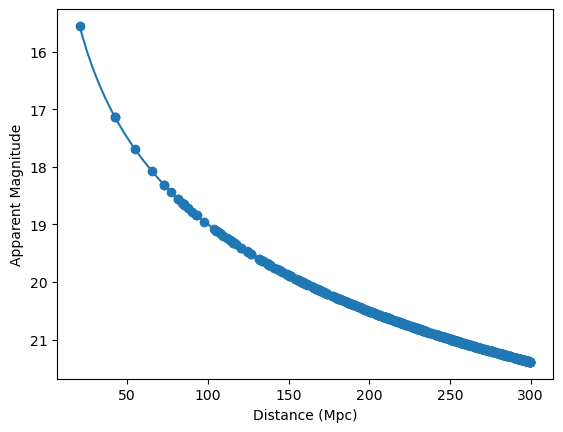

In [10]:

d = np.linspace(events["distance"].min(), 
                events["distance"].max(), 500)

m_model = -16 + 5*np.log10(d*1e6) - 5

plt.figure()
plt.scatter(events["distance"], events["m"])
plt.plot(d, m_model)

plt.xlabel("Distance (Mpc)")
plt.ylabel("Apparent Magnitude")
plt.gca().invert_yaxis()
plt.show()

### Apparent Magnitude Distribution: Supernovae vs Kilonovae

This cell compares the apparent magnitude distributions of Supernovae (SN) and Kilonovae (KN).

- The events are separated by type (`SN` and `KN`).
- Histograms of their apparent magnitudes (`m`) are plotted.
- A logarithmic y-axis is used to clearly show differences in event counts.
- This highlights the relative abundance of SN compared to the much rarer KN population.

The plot allows a direct visual comparison of brightness distributions and population imbalance between the two transient types.


[]

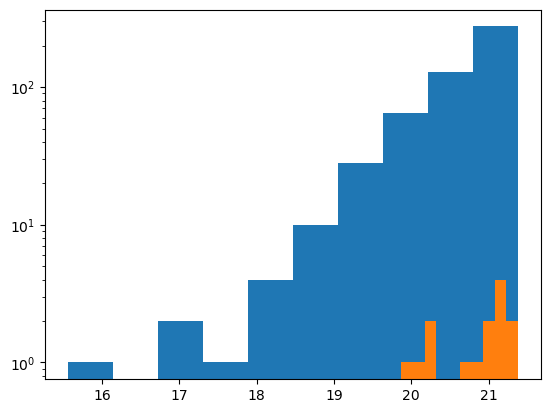

In [11]:
plt.hist(events[events['type']=='SN']['m'], label='SN')
plt.hist(events[events['type']=='KN']['m'], label='KN')

plt.semilogy()

### Inspecting Kilonova Events in the Synthetic Sample

This cell filters the event catalogue to show only Kilonova (KN) events.


In [12]:
events[events['type']=='KN']


,type,distance,mu,m
17,KN,262.972975,37.099556,21.099556
70,KN,229.396704,36.802936,20.802936
116,KN,275.660772,37.201875,21.201875
179,KN,275.333251,37.199293,21.199293
189,KN,246.341424,36.957687,20.957687
209,KN,149.423754,35.872098,19.872098
240,KN,261.697905,37.089001,21.089001
300,KN,163.685405,36.070050,20.070050
353,KN,279.374758,37.230936,21.230936
379,KN,299.265559,37.380284,21.380284


## SN 1993J r-band Light Curve

This cell plots the observed r-band light curve of the Type IIb supernova SN 1993J.

- The x-axis shows time in days since explosion.
- The y-axis shows apparent R-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point is a real observational measurement.

This allows direct visual comparison with AT2017gfo.

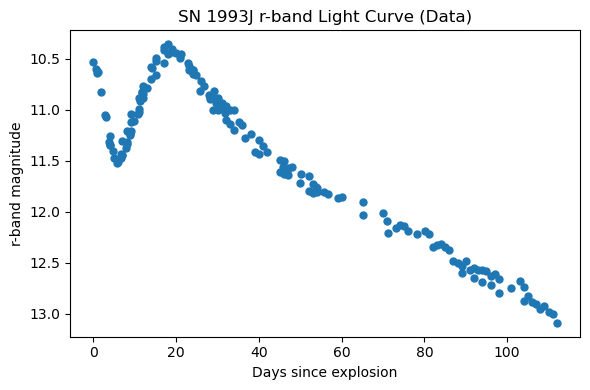

In [13]:
df_93 = pd.read_csv(os.path.expanduser("~/Downloads/sn1993j_rband_shifted.csv"))

plt.figure(figsize=(6,4))
plt.scatter(df_93["t_days"], df_93["R_app"], s=25)

plt.gca().invert_yaxis()
plt.xlabel("Days since explosion")
plt.ylabel("r-band magnitude")
plt.title("SN 1993J r-band Light Curve (Data)")
plt.tight_layout()
plt.show()


### Loading the AT2017gfo r-band Kilonova Data

This cell loads the real photometric data for the kilonova AT2017gfo.

- The file contains multi-band observations compiled from the literature.
- Each row corresponds to a measurement at a given time since merger (`Phase`).
- The `mag` column contains the observed apparent magnitude.
- The `Band` column specifies the filter (we will later isolate r-band only).

This dataset provides a fully data-driven kilonova light curve for direct comparison with the Type IIb supernova.


In [14]:
df_kn = pd.read_csv(os.path.expanduser("~/Downloads/at2017gfo_rband.csv"))
df_kn = df_kn[df_kn["band"] == "r"].copy()
df_kn_r = df_kn   # alias used in later cells

print("Number of r-band points:", len(df_kn))

# Upper-limit mask applied to AT2017gfo r-band data.
# Points after 8 days with mag < 20.5 are treated as upper limits based on
# visual inspection of the light curve, consistent with Villar et al. (2017).
# Points beyond 16 days are treated as upper limits throughout.
mask_kn = ((df_kn_r["Phase"] > 8) & (df_kn_r["mag"] < 20.5)) | (df_kn_r["Phase"] > 16)
kn_det = df_kn_r[~mask_kn]
kn_lim = df_kn_r[mask_kn]

df_kn.head()


Number of r-band points: 101


,t_days,Phase,mag,band,upperlimit
0,0.000,0.000,17.46,r,False
1,0.007,0.007,17.33,r,False
2,0.035,0.035,17.56,r,False
3,0.057,0.057,17.14,r,False
4,0.412,0.412,17.20,r,False


### Selecting Only r-band Kilonova Data

This cell filters the full AT2017gfo dataset to keep only r-band measurements.

- The original table contains multiple photometric bands.
- We restrict to rows where `Band == "r"`.
- A copy of the filtered dataframe is created to avoid modifying the original data.

This ensures we are comparing SN 2011dh and AT2017gfo in the same photometric band.


### AT2017gfo r-band Light Curve


We apply a physical sanity filter:

- Use r-band only  
- Respect published upper limits  
- After 8 days, any point brighter than 20.5 mag is treated as an upper limit  

This prevents artificial late-time rebrightening.


## Apparent r-band Light Curves

This cell plots the observed r-band light curves of SN 1993J and AT2017gfo.

- The x-axis shows time in days since explosion (SN 1993J) or merger (AT2017gfo).
- The y-axis shows apparent r-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point represents a real observational measurement.

This allows direct visual comparison between a Type IIb supernova and a kilonova in the same photometric band.

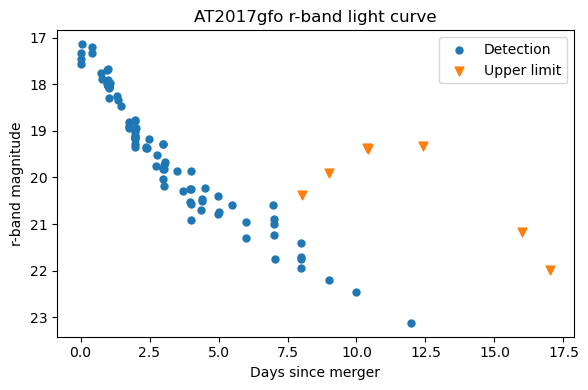

In [15]:
detections   = kn_det
upper_limits = kn_lim

plt.figure(figsize=(6,4))
plt.scatter(detections["Phase"], detections["mag"], s=25, label="Detection")
plt.scatter(upper_limits["Phase"], upper_limits["mag"], marker="v", s=40, label="Upper limit")

plt.gca().invert_yaxis()
plt.xlabel("Days since merger")
plt.ylabel("r-band magnitude")
plt.title("AT2017gfo r-band light curve")
plt.legend()
plt.tight_layout()
plt.show()


## Combined Apparent Light Curves

The apparent r-band light curves of SN 1993J and AT2017gfo are plotted together on the same axes. This comparison illustrates the different fading rates of the two transient types before any distance correction is applied. AT2017gfo is intrinsically fainter but fades far more rapidly than SN 1993J.

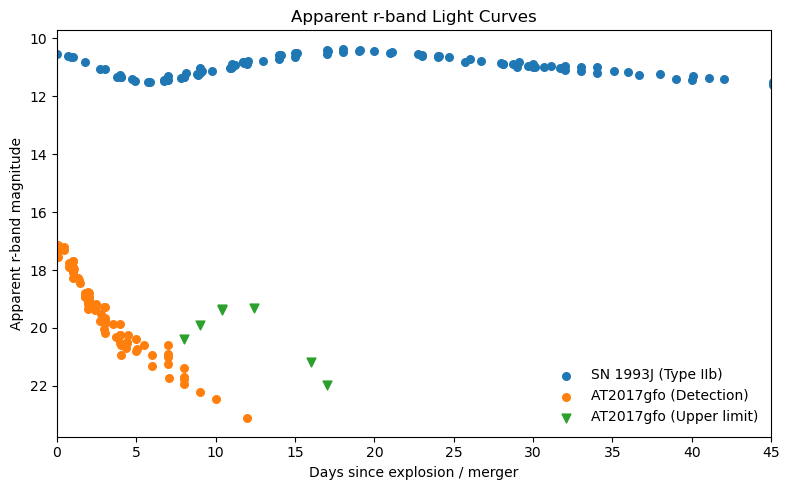

In [16]:
phase_sn = df_93["t_days"]
r_sn = df_93["R_app"]

phase_kn_det = kn_det["Phase"]
r_kn_det = kn_det["mag"]
phase_kn_lim = kn_lim["Phase"]
r_kn_lim = kn_lim["mag"]

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, r_sn, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, r_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, r_kn_lim, marker="v", s=40, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Apparent r-band magnitude")
plt.title("Apparent r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Absolute r-band Light Curves

This cell converts both light curves to absolute magnitude.

- The distance modulus is computed using:
  μ = 5 log10(d_Mpc × 10^6) − 5
- SN 1993J is assumed to be at 3.6 Mpc.
- AT2017gfo is assumed to be at 40 Mpc.
- Absolute magnitude is computed as:
  M = m − μ

This allows direct physical comparison of intrinsic brightness.

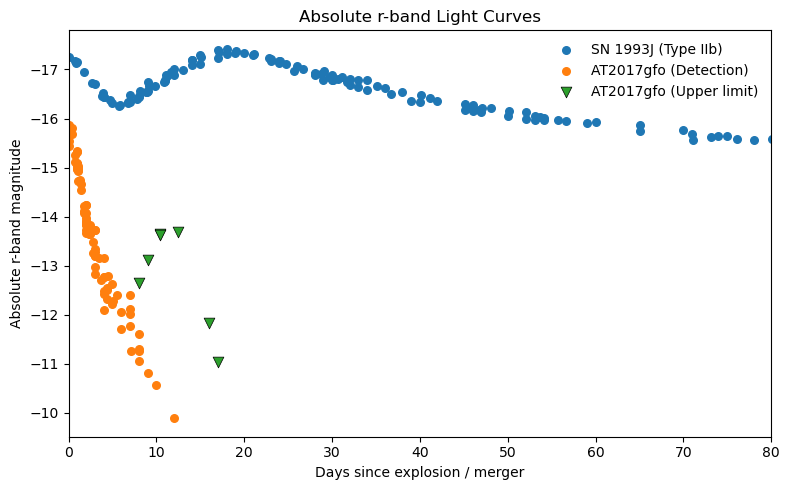

In [17]:
d_93 = 3.6    # Mpc
d_kn = 40.0   # Mpc

mu_93 = 5 * np.log10(d_93 * 1e6) - 5
mu_kn = 5 * np.log10(d_kn * 1e6) - 5

M_93      = r_sn - mu_93
M_kn_det  = r_kn_det - mu_kn
M_kn_lim  = r_kn_lim - mu_kn

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, M_93, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, M_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=60, edgecolor="black", linewidth=0.5, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Absolute r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 80)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## r-band Spline Fitting

The r-band data for both templates are sorted, cleaned of NaNs and duplicate time values, and used to fit smoothing splines. The smoothing parameter controls the balance between interpolation accuracy and curve smoothness. The fitted splines allow the template light curves to be evaluated at arbitrary times during the simulation.

In [18]:
# --- Sort data ---
idx_sn = np.argsort(phase_sn)
phase_sn_sorted = phase_sn.values[idx_sn]
M_sn_sorted     = M_93.values[idx_sn]

idx_kn = np.argsort(phase_kn_det)
phase_kn_sorted = phase_kn_det.values[idx_kn]
M_kn_sorted     = M_kn_det.values[idx_kn]


# --- CLEAN DATA (critical) ---
# remove NaNs
mask_sn = np.isfinite(phase_sn_sorted) & np.isfinite(M_sn_sorted)
phase_sn_sorted = phase_sn_sorted[mask_sn]
M_sn_sorted     = M_sn_sorted[mask_sn]

mask_kn = np.isfinite(phase_kn_sorted) & np.isfinite(M_kn_sorted)
phase_kn_sorted = phase_kn_sorted[mask_kn]
M_kn_sorted     = M_kn_sorted[mask_kn]

# remove duplicate times (required for spline)
phase_sn_sorted, idx_unique_sn = np.unique(phase_sn_sorted, return_index=True)
M_sn_sorted = M_sn_sorted[idx_unique_sn]

phase_kn_sorted, idx_unique_kn = np.unique(phase_kn_sorted, return_index=True)
M_kn_sorted = M_kn_sorted[idx_unique_kn]


# --- Fit splines ---
spline_sn = UnivariateSpline(phase_sn_sorted, M_sn_sorted, s=0.5)
spline_kn = UnivariateSpline(phase_kn_sorted, M_kn_sorted, s=3.9)

# Save raw splines
_spline_sn_raw = spline_sn
_spline_kn_raw = spline_kn


# --- Evaluation grids ---
t_sn = np.linspace(phase_sn_sorted.min(), phase_sn_sorted.max(), 500)
t_kn = np.linspace(phase_kn_sorted.min(), phase_kn_sorted.max(), 500)

M_sn_smooth = _spline_sn_raw(t_sn)
M_kn_smooth = _spline_kn_raw(t_kn)


# --- Sanity checks (must pass) ---
print("SN NaNs:", np.isnan(M_sn_smooth).any())
print("KN NaNs:", np.isnan(M_kn_smooth).any())
print("SN range:", M_sn_smooth.min(), M_sn_smooth.max())
print("KN range:", M_kn_smooth.min(), M_kn_smooth.max())

SN NaNs: False
KN NaNs: False
SN range: -17.46759208089616 -14.756304140767893
KN range: -15.765775812395464 -9.907439702491619


## r-band Template Normalisation

Both r-band splines are shifted so their peaks align at an absolute magnitude of -16. This normalisation places both templates on a common scale for injection into the simulation. Residual scatter and intrinsic diversity are combined into uncertainty bands that characterise the expected variation around each template.

In [19]:
# --- Normalise both templates to the same peak absolute magnitude ---

M_peak = -16.0

sn_offset = M_peak - M_sn_smooth.min()
kn_offset = M_peak - M_kn_smooth.min()

# Apply offsets without modifying raw splines
spline_sn = lambda t: _spline_sn_raw(t) + sn_offset
spline_kn = lambda t: _spline_kn_raw(t) + kn_offset

print(f"SN template shifted by {sn_offset:+.2f} mag (raw peak was {M_sn_smooth.min():.2f})")
print(f"KN template shifted by {kn_offset:+.2f} mag (raw peak was {M_kn_smooth.min():.2f})")


# --- Residual-scatter uncertainty bands ---

sn_resid_std = np.std(M_sn_sorted - _spline_sn_raw(phase_sn_sorted))
kn_resid_std = np.std(M_kn_sorted - _spline_kn_raw(phase_kn_sorted))

SN_INTRINSIC_SCATTER = 0.2   # mag, Type IIb diversity
KN_INTRINSIC_SCATTER = 0.2  # mag, kilonova diversity

sn_band = np.sqrt(sn_resid_std**2 + SN_INTRINSIC_SCATTER**2)
kn_band = np.sqrt(kn_resid_std**2 + KN_INTRINSIC_SCATTER**2)

print(f"SN residual scatter: {sn_resid_std:.3f} mag → band (incl. intrinsic): {sn_band:.3f} mag")
print(f"KN residual scatter: {kn_resid_std:.3f} mag → band (incl. intrinsic): {kn_band:.3f} mag")

SN template shifted by +1.47 mag (raw peak was -17.47)
KN template shifted by -0.23 mag (raw peak was -15.77)
SN residual scatter: 0.060 mag → band (incl. intrinsic): 0.209 mag
KN residual scatter: 0.211 mag → band (incl. intrinsic): 0.290 mag


## r-band Template Plot

The normalised r-band splines are plotted with 1-sigma uncertainty bands derived from residual scatter and assumed intrinsic diversity. The kilonova template fades steeply while the supernova template evolves more slowly, illustrating the photometric basis for the fade rate classifier.

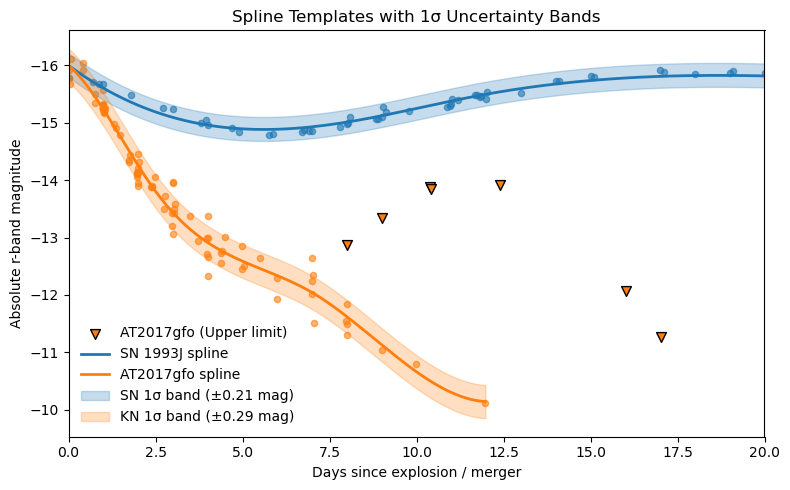

In [20]:
# Plot normalised splines with 1σ uncertainty bands
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(phase_sn_sorted, M_sn_sorted + sn_offset, s=20, alpha=0.6, color="C0")
ax.scatter(phase_kn_sorted, M_kn_sorted + kn_offset, s=20, alpha=0.6, color="C1")
ax.scatter(phase_kn_lim, M_kn_lim + kn_offset, marker="v", s=50, edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")

ax.plot(t_sn, M_sn_smooth + sn_offset, linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn, M_kn_smooth + kn_offset, linewidth=2, color="C1", label="AT2017gfo spline")

ax.fill_between(t_sn,
                M_sn_smooth + sn_offset - sn_band,
                M_sn_smooth + sn_offset + sn_band,
                alpha=0.25, color="C0", label=f"SN 1σ band (±{sn_band:.2f} mag)")
ax.fill_between(t_kn,
                M_kn_smooth + kn_offset - kn_band,
                M_kn_smooth + kn_offset + kn_band,
                alpha=0.25, color="C1", label=f"KN 1σ band (±{kn_band:.2f} mag)")

ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute r-band magnitude")
ax.set_title("Spline Templates with 1σ Uncertainty Bands")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#### Two-Epoch Survey Configuration

We simulate a two-epoch, 24-hour baseline survey designed to represent a
rapid-response LSST-style observing strategy. Observations are made at
t = 0 and t = 1 day after the first detection. This minimal cadence is
sufficient to measure a fade rate and a g-r colour rate, which are the
two features used in the classifier. The LSST single-visit r-band limiting
magnitude of 24.5 is applied. Events fainter than this limit at any epoch
are recorded as non-detections.


In [21]:
np.random.seed(37)


t_obs = np.array([0, 1,])  # days

# LSST single-visit r-band limiting magnitude
m_lim = 24.5


def sample_distance(d_min=50, d_max=300):
    """Draw a distance uniformly in volume (proportional to d^2 dd)."""
    u = np.random.uniform()
    return (d_min**3 + u * (d_max**3 - d_min**3)) ** (1 / 3)


### Observed Light Curve Model

For each injected event, the following steps are applied:

1. Evaluate the absolute magnitude template spline at rest-frame time.
2. Remove pre-explosion epochs (t < 0).
3. Convert to apparent magnitude using the distance modulus:
   μ = 5 log10(d_Mpc × 10^6) − 5
4. Apply magnitude-dependent photometric uncertainty:
   σ = 0.1 mag at 20 mag,
   σ = 0.2 mag at 21 mag,
   linear interpolation between.

Gaussian noise is added to produce observed magnitudes.

In [22]:
def generate_observed_lightcurve(event_type, t0, d_mpc):

    # Rest-frame time
    t_rest = t_obs - t0

    # Evaluate absolute magnitude template
    if event_type == "SN":
        M = spline_sn(t_rest)
    else:
        M = spline_kn(t_rest)

    # Remove pre-explosion epochs
    M = np.array(M)
    M[t_rest < 0] = np.nan

    # Convert to apparent magnitude
    mu = 5 * np.log10(d_mpc * 1e6) - 5
    m_true = M + mu

    # Magnitude-dependent photometric uncertainty (linear 0.1→0.2 over 20–21 mag)
    sigma = np.where(m_true <= 20, 0.1, np.where(m_true >= 21, 0.2, 0.1 + 0.1 * (m_true - 20)))

    # Add Gaussian noise
    m_obs = m_true + np.random.normal(0, sigma)

    return m_obs, sigma


### Injection of 1 Kilonova and 50 Supernovae

We inject:
- 1 kilonova
- 50 Type IIb supernovae

Distances are drawn uniformly between 50 and 300 Mpc.

Explosion times are drawn uniformly between −1 and 0 days,
allowing events to be partially evolved at first detection.

This configuration approximates the expected contamination level in a 1000 deg² survey over 96 hours.

In [23]:
# --- Kilonova ---
kn_distance = sample_distance()
kn_t0 = np.random.uniform(-1, 0)
kn_lc, kn_sigma = generate_observed_lightcurve("KN", kn_t0, kn_distance)
kn_lc[kn_lc > m_lim] = np.nan   # epochs below limiting magnitude → non-detection

print(f"KN: d = {kn_distance:.1f} Mpc,  detected epochs = {np.sum(~np.isnan(kn_lc))} / {len(t_obs)}")

# --- Supernovae ---
sn_lcs = []
sn_sigmas = []

for _ in range(50):
    d = sample_distance()
    t0 = np.random.uniform(-1, 0)
    m_obs, sig = generate_observed_lightcurve("SN", t0, d)
    m_obs[m_obs > m_lim] = np.nan   # apply limiting magnitude
    sn_lcs.append(m_obs)
    sn_sigmas.append(sig)


KN: d = 294.4 Mpc,  detected epochs = 2 / 2


### 24-Hour Light Curve Comparison

Observed light curves are plotted over the four survey epochs.

Supernovae are shown in grey.
The kilonova is shown in red.

Over a 3 day baseline:
- Supernovae exhibit minimal magnitude evolution.
- Kilonovae exhibit rapid fading.

Separation between populations is therefore driven primarily by the measured light curve slope.

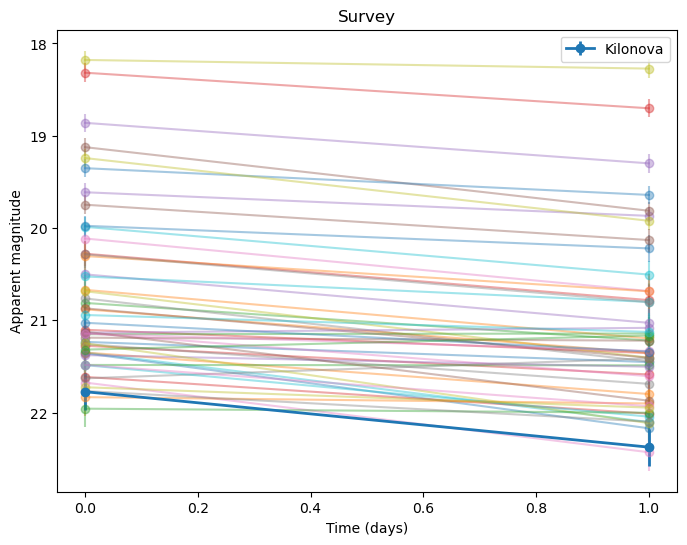

In [24]:
plt.figure(figsize=(8,6))

# Supernovae
for lc, sig in zip(sn_lcs, sn_sigmas):
    plt.errorbar(t_obs, lc, yerr=sig, fmt='o-', alpha=0.4)

# Kilonova
plt.errorbar(t_obs, kn_lc, yerr=kn_sigma, fmt='o-', linewidth=2, label="Kilonova")

plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Apparent magnitude")
plt.title("Survey")
plt.legend()
plt.show()

### Fade-Rate Classifier

To separate kilonovae from supernovae, a simple classifier based on how fast the light curve fades was used. Kilonovae fade much faster than supernovae during the first few days after peak brightness.

For each simulated light curve, the fade rate was estimated by comparing the brightness at the first detected observation and the last detected observation. Only valid detections were used. If fewer than two detections were available, the fade rate could not be calculated.

A threshold of **0.35 magnitudes per day** was used for classification.  
- If an event faded faster than this threshold, it was classified as a **kilonova candidate**.  
- If it faded more slowly, it was classified as a **supernova**.

The histogram shows the distribution of fade rates measured for the simulated supernova population. The red vertical line marks the fade rate of the injected kilonova, and the dashed black line shows the classification threshold.

KN fade rate : 0.601 mag/day  →  KN ✓
SN fade rates: ['0.219', '0.526', '0.407', '0.311', '0.256', '0.032', '0.569', '0.683', '0.094', '0.754', '0.813', '0.450', '0.004', '0.253', '0.525', '0.689', '0.755', '0.430', '0.720', '0.517', '0.245', '0.472', '-0.008', '0.398', '0.126', '0.535', '0.468', '-0.216', '0.865', '0.558', '0.290', '0.068', '0.044', '0.503', '-0.053', '0.749', '0.187', '0.331', '0.679', '0.276', '0.312', '0.382', '-0.153', '0.385', '0.439', '0.383', '0.448', '0.518', '0.221', '0.183']
SN false positives (misclassified as KN): 28 / 50


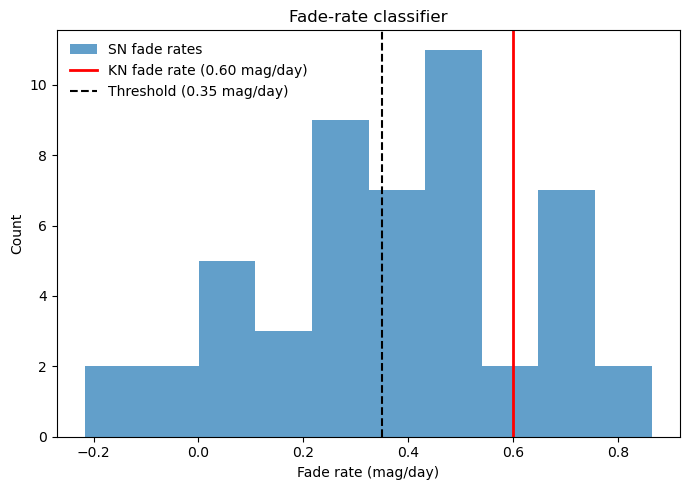

In [25]:
# --- Fade-rate classifier ---
# Kilonovae fade > ~ 
KN_FADE_THRESHOLD = 0.35 # mag/day


def fade_rate(m_obs):
    """Linear fade rate (mag/day) over detected epochs. Returns NaN if < 2 detections."""
    valid = ~np.isnan(m_obs)
    if valid.sum() < 2:
        return np.nan
    t_valid = t_obs[valid]
    m_valid = m_obs[valid]
    # Positive = fading (getting fainter)
    return (m_valid[-1] - m_valid[0]) / (t_valid[-1] - t_valid[0])


kn_rate = fade_rate(kn_lc)
sn_rates = np.array([fade_rate(lc) for lc in sn_lcs])

# Classify
kn_label = "KN ✓" if (not np.isnan(kn_rate) and kn_rate > KN_FADE_THRESHOLD) else "SN ✗ (missed)"
sn_fp = np.sum(sn_rates[~np.isnan(sn_rates)] > KN_FADE_THRESHOLD)
sn_valid = np.sum(~np.isnan(sn_rates))

print(f"KN fade rate : {kn_rate:.3f} mag/day  →  {kn_label}")
print(f"SN fade rates: {[f'{r:.3f}' for r in sn_rates if not np.isnan(r)]}")
print(f"SN false positives (misclassified as KN): {sn_fp} / {sn_valid}")

# Plot fade-rate distributions
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(sn_rates[~np.isnan(sn_rates)], bins=10, label="SN fade rates", alpha=0.7)
if not np.isnan(kn_rate):
    ax.axvline(kn_rate, color="red", linewidth=2, label=f"KN fade rate ({kn_rate:.2f} mag/day)")
ax.axvline(KN_FADE_THRESHOLD, color="black", linestyle="--", label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("Count")
ax.set_title("Fade-rate classifier")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Multi-Seed Survey Simulation

The survey was simulated **100 times with different random seeds**.

In each simulation:

- **1 kilonova** and **50 supernovae** were injected at random distances and explosion times.
- Light curves were generated using the survey cadence and limiting magnitude.
- Fade rates were calculated and the same **0.35 mag/day threshold** was used for classification.

In [26]:
# --- Multi-seed survey simulation (seeds 1–100) ---
# Re-uses all existing functions and parameters unchanged.

results = []

for seed in range(1, 101):
    np.random.seed(seed)

    # Inject 1 KN
    kn_d = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_lc, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_lc[kn_lc > m_lim] = np.nan

    # Inject 50 SNe
    sn_rates_seed = []
    for _ in range(50):
        d = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_obs, _ = generate_observed_lightcurve("SN", t0, d)
        m_obs[m_obs > m_lim] = np.nan
        sn_rates_seed.append(fade_rate(m_obs))

    kn_r = fade_rate(kn_lc)
    sn_r = np.array(sn_rates_seed)

    results.append({
        "seed":               seed,
        "kn_distance":        kn_d,
        "kn_fade_rate":       kn_r,
        "kn_detected":        (not np.isnan(kn_r)) and (kn_r > KN_FADE_THRESHOLD),
        "sn_false_positives": int(np.sum(sn_r[~np.isnan(sn_r)] > KN_FADE_THRESHOLD)),
        "sn_valid":           int(np.sum(~np.isnan(sn_r))),
    })

results_df = pd.DataFrame(results)
print(f"KN detection rate:       {results_df['kn_detected'].mean()*100:.1f}%  "
      f"({results_df['kn_detected'].sum()} / 100 seeds)")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f} per realisation")


KN detection rate:       98.0%  (98 / 100 seeds)
Mean SN false positives: 24.48 per realisation


## Bootstrap Confidence Intervals

Bootstrap resampling over the 100 seeds is used to compute 95% confidence
intervals on the KN detection rate and mean SN false positive count. Note
that only 100 resamples are used here for speed. Standard practice recommends
at least 1000 resamples for stable confidence interval estimates. The intervals
reported here should be interpreted as approximate.


In [27]:
# --- Bootstrap confidence intervals on detection rate (100 resamples) ---
n_seeds = len(results_df)
kn_detected_arr = results_df["kn_detected"].values
sn_fp_arr = results_df["sn_false_positives"].values

rng = np.random.default_rng(42)
boot_kn_rate = []
boot_sn_fp   = []
for _ in range(100):
    idx = rng.integers(0, n_seeds, size=n_seeds)
    boot_kn_rate.append(kn_detected_arr[idx].mean())
    boot_sn_fp.append(sn_fp_arr[idx].mean())

boot_kn_rate = np.array(boot_kn_rate)
boot_sn_fp   = np.array(boot_sn_fp)

kn_lo, kn_hi = np.percentile(boot_kn_rate, [2.5, 97.5])
fp_lo, fp_hi = np.percentile(boot_sn_fp,   [2.5, 97.5])

print(f"KN detection rate: {results_df['kn_detected'].mean()*100:.1f}%  "
      f"95% CI: [{kn_lo*100:.1f}%, {kn_hi*100:.1f}%]")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f}  "
      f"95% CI: [{fp_lo:.2f}, {fp_hi:.2f}]")

KN detection rate: 98.0%  95% CI: [95.0%, 100.0%]
Mean SN false positives: 24.48  95% CI: [23.76, 24.95]


### Classifier Performance Across 100 Simulations

The performance of the fade-rate classifier was examined using 100 independent survey simulations.

The left panel shows the distribution of measured kilonova fade rates. The dashed line marks the classification threshold of **0.35 mag/day**. 

The middle panel shows the number of supernovae that are incorrectly classified as kilonovae in each simulation. On average, several fast-fading supernovae contaminate the kilonova sample.

The right panel shows kilonova fade rate as a function of distance. Orange points indicate correctly detected kilonovae, while grey points show missed events. Missed detections occur when the measured fade rate falls below the classification threshold.

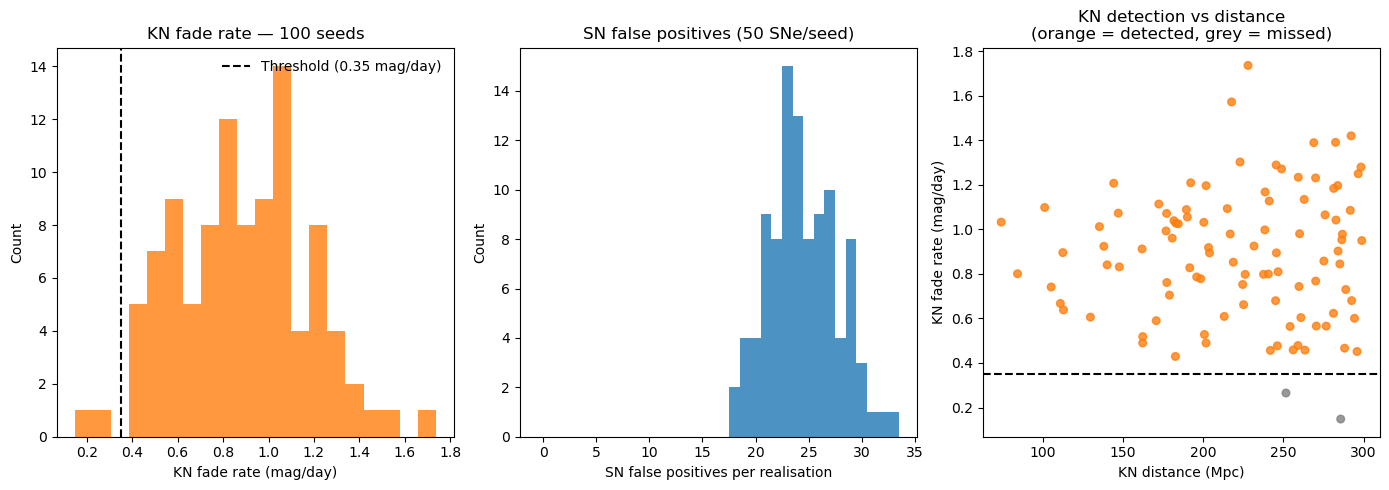

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# Panel 1 — KN fade-rate distribution
axes[0].hist(results_df["kn_fade_rate"].dropna(), bins=20, color="C1", alpha=0.8)
axes[0].axvline(KN_FADE_THRESHOLD, color="black", linestyle="--",
                label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
axes[0].set_xlabel("KN fade rate (mag/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("KN fade rate — 100 seeds")
axes[0].legend(frameon=False)

# Panel 2 — SN false-positive count per realisation
fp_max = max(results_df["sn_false_positives"].max(), 1)
axes[1].hist(results_df["sn_false_positives"], bins=range(0, fp_max + 2),
             color="C0", alpha=0.8, align="left")
axes[1].set_xlabel("SN false positives per realisation")
axes[1].set_ylabel("Count")
axes[1].set_title("SN false positives (50 SNe/seed)")

# Panel 3 — KN detection vs distance
colors = results_df["kn_detected"].map({True: "C1", False: "grey"})
axes[2].scatter(results_df["kn_distance"], results_df["kn_fade_rate"],
                c=colors, s=30, alpha=0.8)
axes[2].axhline(KN_FADE_THRESHOLD, color="black", linestyle="--")
axes[2].set_xlabel("KN distance (Mpc)")
axes[2].set_ylabel("KN fade rate (mag/day)")
axes[2].set_title("KN detection vs distance\n(orange = detected, grey = missed)")

plt.tight_layout()
plt.show()

### ROC Curve Calculation

The classifier threshold is scanned across the full range of measured fade rates. For each threshold, events with a fade rate above the threshold are classified as kilonova candidates.

At every threshold the fraction of real kilonovae correctly identified and the fraction of supernovae incorrectly classified as kilonovae are calculated.

These values are used to construct the Receiver Operating Characteristic (ROC) curve. The ROC curve shows how the detection efficiency changes as the classification threshold is varied.

The area under the ROC curve (AUC) is then computed to summarise the overall performance of the classifier. A value close to one indicates strong separation between kilonovae and supernovae.

Finally, the operating point corresponding to the adopted threshold of **0.35 mag/day** is identified on the ROC curve.

In [29]:
# --- Build score arrays for ROC analysis ---
# Collect all per-event fade rates across all 100 seeds.

kn_scores_list = []
sn_scores_list = []

for seed in range(1, 101):
    np.random.seed(seed)

    # KN
    kn_d = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_lc_r, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_lc_r[kn_lc_r > m_lim] = np.nan
    r = fade_rate(kn_lc_r)
    if not np.isnan(r):
        kn_scores_list.append(r)

    # 50 SNe
    for _ in range(50):
        d = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_obs, _ = generate_observed_lightcurve("SN", t0, d)
        m_obs[m_obs > m_lim] = np.nan
        r = fade_rate(m_obs)
        if not np.isnan(r):
            sn_scores_list.append(r)

all_scores = np.concatenate([kn_scores_list, sn_scores_list])
all_labels = np.concatenate([np.ones(len(kn_scores_list)), np.zeros(len(sn_scores_list))])

n_kn = len(kn_scores_list)
n_sn = len(sn_scores_list)

print(f"KN events with valid fade rate: {n_kn}")
print(f"SN events with valid fade rate: {n_sn}")


KN events with valid fade rate: 100
SN events with valid fade rate: 5000


## ROC Threshold Sweep

The classifier threshold is swept from the minimum to maximum observed fade rate. At each threshold, the true positive rate and false positive rate are computed. The AUC is calculated using the trapezoidal rule after sorting by false positive rate, and the operating point at the chosen threshold is marked.

In [30]:
# Sweep thresholds from min to max fade rate
thresholds = np.linspace(all_scores.min() - 0.01, all_scores.max() + 0.01, 500)

tpr_vals, fpr_vals, prec_vals = [], [], []
for t in thresholds:
    pred_pos = all_scores >= t
    tp = ((pred_pos) & (all_labels == 1)).sum()
    fp = ((pred_pos) & (all_labels == 0)).sum()
    tpr_vals.append(tp / n_kn if n_kn > 0 else 0)
    fpr_vals.append(fp / n_sn if n_sn > 0 else 0)
    prec_vals.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)

tpr_vals  = np.array(tpr_vals)
fpr_vals  = np.array(fpr_vals)
prec_vals = np.array(prec_vals)

# AUC via trapezoidal rule (sort by FPR for proper integration)
sort_idx = np.argsort(fpr_vals)
auc = np.trapezoid(tpr_vals[sort_idx], fpr_vals[sort_idx])

# Mark operating point at KN_FADE_THRESHOLD
op_idx = np.argmin(np.abs(thresholds - KN_FADE_THRESHOLD))
op_fpr  = fpr_vals[op_idx]
op_tpr  = tpr_vals[op_idx]
op_prec = prec_vals[op_idx]
op_rec  = tpr_vals[op_idx]   # recall = TPR

## AUC Bootstrap Confidence Interval

Bootstrap resampling over the per-event score arrays is used to compute a 95% confidence interval on the AUC. KN and SN score arrays are resampled independently to preserve the class sizes. This quantifies the uncertainty in the AUC arising from the finite number of simulated events.

In [31]:
# --- Bootstrap confidence interval on AUC (100 resamples) ---
kn_scores = all_scores[all_labels == 1]
sn_scores = all_scores[all_labels == 0]

boot_aucs = []
rng2 = np.random.default_rng(42)
for _ in range(100):
    kn_boot = rng2.choice(kn_scores, size=len(kn_scores), replace=True)
    sn_boot = rng2.choice(sn_scores, size=len(sn_scores), replace=True)
    boot_all_scores = np.concatenate([kn_boot, sn_boot])
    boot_all_labels = np.concatenate([np.ones(len(kn_boot)), np.zeros(len(sn_boot))])

    boot_tpr, boot_fpr = [], []
    for t in thresholds:
        pred = boot_all_scores >= t
        tp = ((pred) & (boot_all_labels == 1)).sum()
        fp = ((pred) & (boot_all_labels == 0)).sum()
        boot_tpr.append(tp / len(kn_boot) if len(kn_boot) > 0 else 0)
        boot_fpr.append(fp / len(sn_boot) if len(sn_boot) > 0 else 0)

    s = np.argsort(boot_fpr)
    boot_aucs.append(np.trapezoid(np.array(boot_tpr)[s], np.array(boot_fpr)[s]))

auc_lo, auc_hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"AUC = {auc:.3f}  95% CI: [{auc_lo:.3f}, {auc_hi:.3f}]")

AUC = 0.918  95% CI: [0.891, 0.942]


## 1D ROC Curve

The ROC curve for the fade rate alone classifier is plotted with its AUC and 95% confidence interval. The operating point at the 0.35 mag/day threshold is marked. This establishes the baseline classifier performance against which the two-feature classifier will be compared.

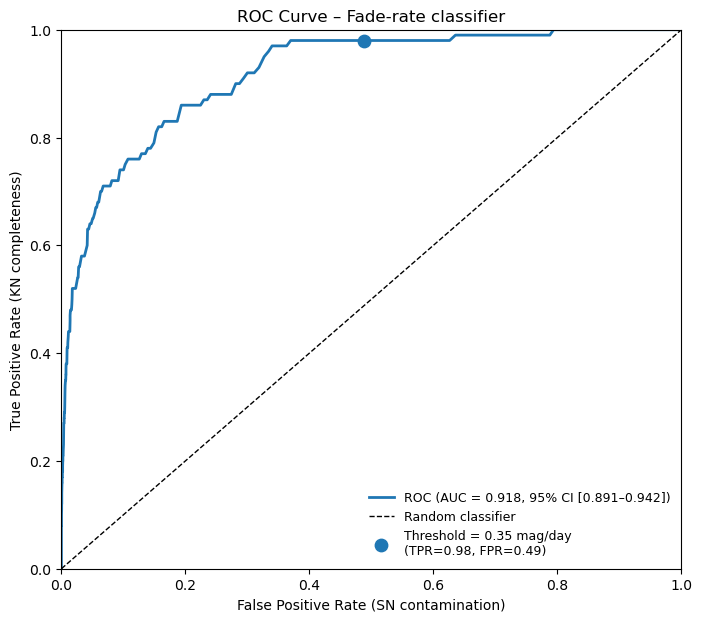

In [32]:
fig, ax = plt.subplots(figsize=(8,7))

ax.plot(fpr_vals, tpr_vals, linewidth=2, label=f"ROC (AUC = {auc:.3f}, 95% CI [{auc_lo:.3f}–{auc_hi:.3f}])")
ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random classifier")

ax.scatter([op_fpr], [op_tpr], s=80, zorder=5,
           label=f"Threshold = {KN_FADE_THRESHOLD} mag/day\n"
                 f"(TPR={op_tpr:.2f}, FPR={op_fpr:.2f})")

ax.set_xlabel("False Positive Rate (SN contamination)")
ax.set_ylabel("True Positive Rate (KN completeness)")
ax.set_title("ROC Curve – Fade-rate classifier")
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.show()


## Loading g-band Light Curve Templates

We load the g-band observations for SN 1993J and AT2017gfo from the standardised CSV files (columns: `t_days`, `mag`, `mag_err`, `band`, `upperlimit`). For AT2017gfo we keep only the 52 real detections — the 11 upper limits mark epochs where the rapidly fading kilonova fell below the g-band detection threshold.

In [33]:
df_sn_g = pd.read_csv(os.path.expanduser('~/Downloads/sn1993j_gband.csv'))
df_kn_g = pd.read_csv(os.path.expanduser('~/Downloads/at2017gfo_gband.csv'))

print(f"SN 1993J g-band : {len(df_sn_g)} points, "
      f"t = {df_sn_g['t_days'].min():.1f}-{df_sn_g['t_days'].max():.1f} d, "
      f"mag = {df_sn_g['mag'].min():.2f}-{df_sn_g['mag'].max():.2f}")

print(f"AT2017gfo g-band : {len(df_kn_g)} points, "
      f"t = {df_kn_g['t_days'].min():.2f}-{df_kn_g['t_days'].max():.2f} d, "
      f"mag = {df_kn_g['mag'].min():.2f}-{df_kn_g['mag'].max():.2f}")

SN 1993J g-band : 163 points, t = 0.0-110.3 d, mag = 10.77-14.31
AT2017gfo g-band : 63 points, t = 0.00-12.39 d, mag = 17.28-23.28


## Raw g-band Light Curves

The raw apparent g-band light curves for both templates are plotted. This provides a visual check of the data quality and time coverage before any conversion to absolute magnitude. The rapidly declining AT2017gfo g-band brightness is immediately apparent compared to the slower evolution of SN 1993J.

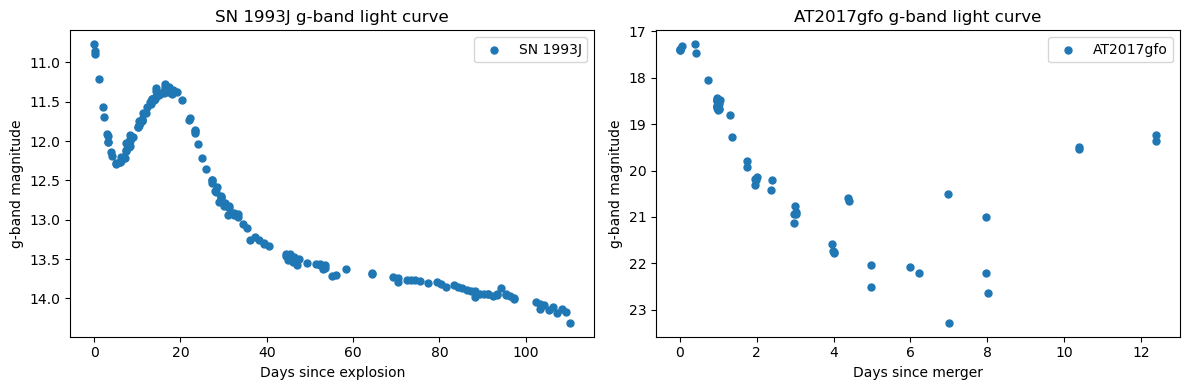

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_sn_g["t_days"], df_sn_g["mag"], s=25, label="SN 1993J")
axes[0].invert_yaxis()
axes[0].set_xlabel("Days since explosion")
axes[0].set_ylabel("g-band magnitude")
axes[0].set_title("SN 1993J g-band light curve")
axes[0].legend()

axes[1].scatter(df_kn_g["t_days"], df_kn_g["mag"], s=25, label="AT2017gfo")
axes[1].invert_yaxis()
axes[1].set_xlabel("Days since merger")
axes[1].set_ylabel("g-band magnitude")
axes[1].set_title("AT2017gfo g-band light curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## AT2017gfo g-band Absolute Magnitudes

The AT2017gfo g-band apparent magnitudes are converted to absolute magnitudes using its known distance of 40 Mpc. A manual upper limit mask is applied using hardcoded time windows corresponding to epochs identified as non-detections in the literature. The resulting detections and upper limits are stored separately.

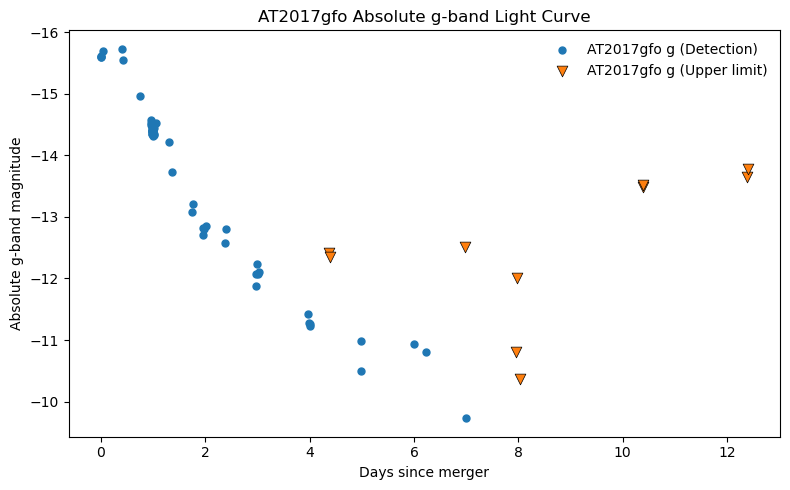

In [35]:
d_kn_g = 40.0  # Mpc
mu_kn_g = 5 * np.log10(d_kn_g * 1e6) - 5

# Manual upper limit mask for AT2017gfo g-band data.
# Time windows were identified by visual inspection of the published
# AT2017gfo photometry. Points in these windows correspond to epochs
# where the source was not significantly detected and published flux
# values represent upper bounds only.
mask_kn_g = (
    ((df_kn_g["t_days"] > 4.323) & (df_kn_g["t_days"] < 4.523)) |
    ((df_kn_g["t_days"] > 6.976) & (df_kn_g["t_days"] < 6.983)) |
    ((df_kn_g["t_days"] > 7.923) & (df_kn_g["t_days"] < 8.123)) |
    (df_kn_g["t_days"] > 9.523)
)

kn_g_det = df_kn_g[~mask_kn_g].copy()
kn_g_lim = df_kn_g[mask_kn_g].copy()

kn_g_det["M"] = kn_g_det["mag"] - mu_kn_g
kn_g_lim["M"] = kn_g_lim["mag"] - mu_kn_g

plt.figure(figsize=(8, 5))
plt.scatter(kn_g_det["t_days"], kn_g_det["M"], s=25, label="AT2017gfo g (Detection)")
plt.scatter(kn_g_lim["t_days"], kn_g_lim["M"], marker="v", s=60,
            edgecolor="black", linewidth=0.5, label="AT2017gfo g (Upper limit)")
plt.gca().invert_yaxis()
plt.xlabel("Days since merger")
plt.ylabel("Absolute g-band magnitude")
plt.title("AT2017gfo Absolute g-band Light Curve")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## SN 1993J g-band Absolute Magnitudes

The SN 1993J g-band data are converted to absolute magnitudes using its distance of 3.6 Mpc. The phase and absolute magnitude arrays are extracted ready for spline fitting. This step mirrors the r-band treatment applied earlier and ensures both templates are on a consistent absolute magnitude scale.

In [36]:
mu_93_g = 5 * np.log10(d_93 * 1e6) - 5   # d_93 = 3.6 Mpc, defined in cell 30

phase_sn_g = df_sn_g["t_days"]
M_sn_g     = df_sn_g["mag"] - mu_93_g

phase_kn_g_det = kn_g_det["t_days"]
M_kn_g_det     = kn_g_det["M"]

phase_kn_g_lim = kn_g_lim["t_days"]
M_kn_g_lim     = kn_g_lim["M"]

## g-band Spline Fitting

The g-band data for both templates are sorted, cleaned, and used to fit smoothing splines. The same cleaning procedure applied to the r-band data is repeated here. The fitted splines are saved as raw spline objects so that the normalisation offset can be applied separately without modifying the underlying fits.

In [37]:
# Smoothing parameters (s) were chosen by visual inspection of spline residuals.
# s=0.5 for SN 1993J gives a close fit to the well-sampled light curve.
# s=3.0 for AT2017gfo allows more flexibility given the sparser g-band coverage.

# Sort data
idx_sn_g = np.argsort(phase_sn_g)
phase_sn_g_sorted = phase_sn_g.values[idx_sn_g]
M_sn_g_sorted = M_sn_g.values[idx_sn_g]

idx_kn_g = np.argsort(phase_kn_g_det)
phase_kn_g_sorted = phase_kn_g_det.values[idx_kn_g]
M_kn_g_sorted = M_kn_g_det.values[idx_kn_g]


# --- CLEAN DATA (critical) ---
# Remove NaNs
mask_sn_g = np.isfinite(phase_sn_g_sorted) & np.isfinite(M_sn_g_sorted)
phase_sn_g_sorted = phase_sn_g_sorted[mask_sn_g]
M_sn_g_sorted     = M_sn_g_sorted[mask_sn_g]

mask_kn_g = np.isfinite(phase_kn_g_sorted) & np.isfinite(M_kn_g_sorted)
phase_kn_g_sorted = phase_kn_g_sorted[mask_kn_g]
M_kn_g_sorted     = M_kn_g_sorted[mask_kn_g]

# Remove duplicate times (required for spline)
phase_sn_g_sorted, idx_unique_sn_g = np.unique(phase_sn_g_sorted, return_index=True)
M_sn_g_sorted = M_sn_g_sorted[idx_unique_sn_g]

phase_kn_g_sorted, idx_unique_kn_g = np.unique(phase_kn_g_sorted, return_index=True)
M_kn_g_sorted = M_kn_g_sorted[idx_unique_kn_g]

# --- Fit splines ---
spline_sn_g = UnivariateSpline(phase_sn_g_sorted, M_sn_g_sorted, s=0.5)
spline_kn_g = UnivariateSpline(phase_kn_g_sorted, M_kn_g_sorted, s=3.0)

# Save raw splines
_spline_sn_g_raw = spline_sn_g
_spline_kn_g_raw = spline_kn_g

# --- Evaluation grids ---
t_sn_g = np.linspace(phase_sn_g_sorted.min(), phase_sn_g_sorted.max(), 500)
t_kn_g = np.linspace(phase_kn_g_sorted.min(), phase_kn_g_sorted.max(), 500)

M_sn_g_smooth = _spline_sn_g_raw(t_sn_g)
M_kn_g_smooth = _spline_kn_g_raw(t_kn_g)

# --- Sanity checks ---
print("SN NaN:", np.isnan(M_sn_g_smooth).any())
print("KN NaN:", np.isnan(M_kn_g_smooth).any())
print("SN range:", M_sn_g_smooth.min(), M_sn_g_smooth.max())
print("KN range:", M_kn_g_smooth.min(), M_kn_g_smooth.max())

SN NaN: False
KN NaN: False
SN range: -17.08693760308302 -13.565733582589186
KN range: -15.94162599545776 -10.221508406404057


## g-band Normalisation

The g-band splines are shifted using the same offset computed for the r-band templates. This anchors the g-band normalisation to the r-band and preserves the physical g-r colour difference between the two objects. Independent g-band normalisation would artificially eliminate the colour separation that makes this feature informative.

SN 1993J  g-r at day 1: +0.53 mag
AT2017gfo g-r at day 1: +0.66 mag
KN should be redder (larger g-r) than SN


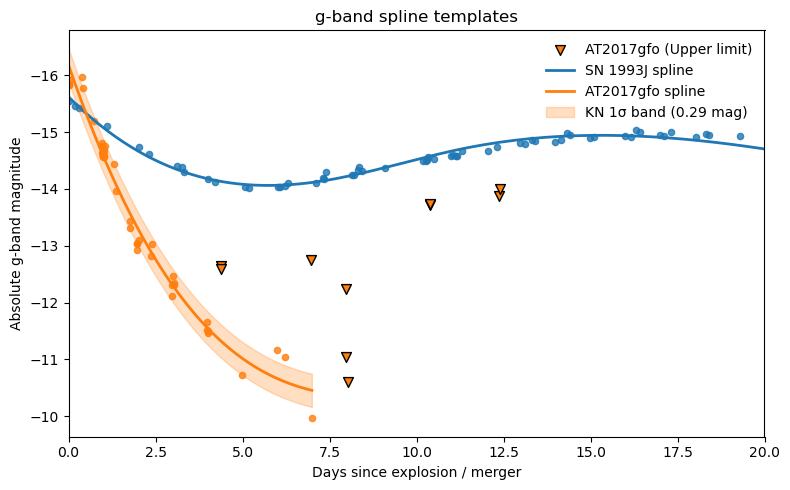

In [38]:
# Normalise g-band using the SAME offset as r-band
# This preserves the real g-r colour difference between the two objects

spline_sn_g = lambda t: _spline_sn_g_raw(t) + sn_offset   # sn_offset from r-band cell
spline_kn_g = lambda t: _spline_kn_g_raw(t) + kn_offset   # kn_offset from r-band cell

# Residual scatter + uncertainty bands (unchanged)
sn_resid_std_g = np.std(M_sn_g_sorted - _spline_sn_g_raw(phase_sn_g_sorted))
kn_resid_std_g = np.std(M_kn_g_sorted - _spline_kn_g_raw(phase_kn_g_sorted))

sn_band_g = np.sqrt(sn_resid_std_g**2 + SN_INTRINSIC_SCATTER**2)
kn_band_g = np.sqrt(kn_resid_std_g**2 + KN_INTRINSIC_SCATTER**2)

# Sanity check — print peak g-r colour for both objects
t_check = np.array([1.0])
gr_sn_peak = spline_sn_g(t_check) - spline_sn(t_check)
gr_kn_peak = spline_kn_g(t_check) - spline_kn(t_check)
print(f"SN 1993J  g-r at day 1: {gr_sn_peak[0]:+.2f} mag")
print(f"AT2017gfo g-r at day 1: {gr_kn_peak[0]:+.2f} mag")
print("KN should be redder (larger g-r) than SN")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(phase_sn_g_sorted, M_sn_g_sorted + sn_offset, s=20, alpha=0.8, color="C0")
ax.scatter(phase_kn_g_sorted, M_kn_g_sorted + kn_offset, s=20, alpha=0.8, color="C1")
ax.scatter(phase_kn_g_lim, M_kn_g_lim + kn_offset, marker="v", s=50,
           edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")

ax.plot(t_sn_g, spline_sn_g(t_sn_g), linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn_g, spline_kn_g(t_kn_g), linewidth=2, color="C1", label="AT2017gfo spline")

ax.fill_between(t_kn_g,
                spline_kn_g(t_kn_g) - kn_band_g,
                spline_kn_g(t_kn_g) + kn_band_g,
                alpha=0.25, color="C1", label=f"KN 1σ band ({kn_band_g:.2f} mag)")

ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute g-band magnitude")
ax.set_title("g-band spline templates")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Side-by-Side Template Plots

The normalised r-band and g-band spline templates are plotted side by side with 1-sigma uncertainty bands. This allows a direct visual comparison of the two bands for both templates. The different rates of decline in g and r are the physical basis for the colour rate feature introduced in the next section.

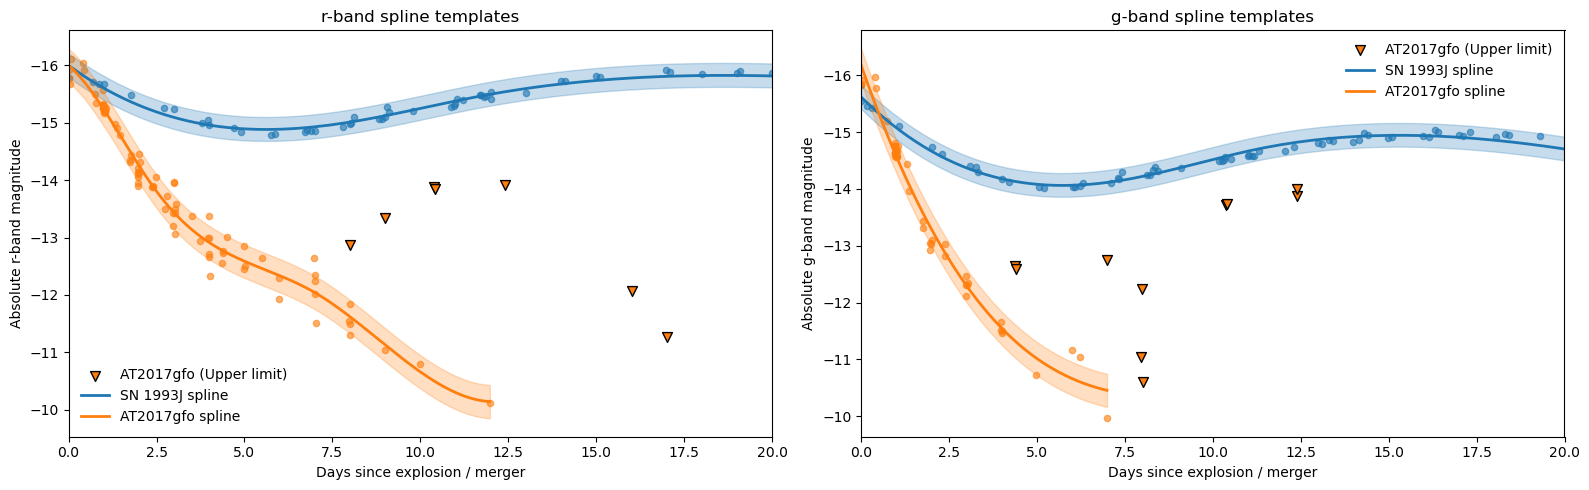

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- r-band ---
ax = axes[0]
ax.scatter(phase_sn_sorted, M_sn_sorted + sn_offset, s=20, alpha=0.6, color="C0")
ax.scatter(phase_kn_sorted, M_kn_sorted + kn_offset, s=20, alpha=0.6, color="C1")
ax.scatter(phase_kn_lim, M_kn_lim + kn_offset, marker="v", s=50,
           edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")
ax.plot(t_sn, M_sn_smooth + sn_offset, linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn, M_kn_smooth + kn_offset, linewidth=2, color="C1", label="AT2017gfo spline")
ax.fill_between(t_sn, M_sn_smooth + sn_offset - sn_band,
                M_sn_smooth + sn_offset + sn_band, alpha=0.25, color="C0")
ax.fill_between(t_kn, M_kn_smooth + kn_offset - kn_band,
                M_kn_smooth + kn_offset + kn_band, alpha=0.25, color="C1")
ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute r-band magnitude")
ax.set_title("r-band spline templates")
ax.legend(frameon=False)

# --- g-band ---
# Uses same sn_offset / kn_offset as r-band (physically correct normalisation)
ax = axes[1]
ax.scatter(phase_sn_g_sorted, M_sn_g_sorted + sn_offset, s=20, alpha=0.6, color="C0")
ax.scatter(phase_kn_g_sorted, M_kn_g_sorted + kn_offset, s=20, alpha=0.6, color="C1")
ax.scatter(phase_kn_g_lim, M_kn_g_lim + kn_offset, marker="v", s=50,
           edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")
ax.plot(t_sn_g, spline_sn_g(t_sn_g), linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn_g, spline_kn_g(t_kn_g), linewidth=2, color="C1", label="AT2017gfo spline")
ax.fill_between(t_sn_g, spline_sn_g(t_sn_g) - sn_band_g,
                spline_sn_g(t_sn_g) + sn_band_g, alpha=0.25, color="C0")
ax.fill_between(t_kn_g, spline_kn_g(t_kn_g) - kn_band_g,
                spline_kn_g(t_kn_g) + kn_band_g, alpha=0.25, color="C1")
ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute g-band magnitude")
ax.set_title("g-band spline templates")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


## g-r Colour Evolution

The g-r colour is computed from the corrected splines on a common time grid and plotted for both templates. AT2017gfo reddens rapidly as the blue ejecta component fades within hours and the red lanthanide component dominates. SN 1993J evolves much more slowly in colour. The colour rate threshold is set at the midpoint between the two template values at the observed epochs.

SN 1993J  g-r at day 1: +0.53 mag
AT2017gfo g-r at day 1: +0.66 mag
Note: this absolute colour feature was investigated but not used in the
final classifier. The colour rate (rate of change) is used instead.


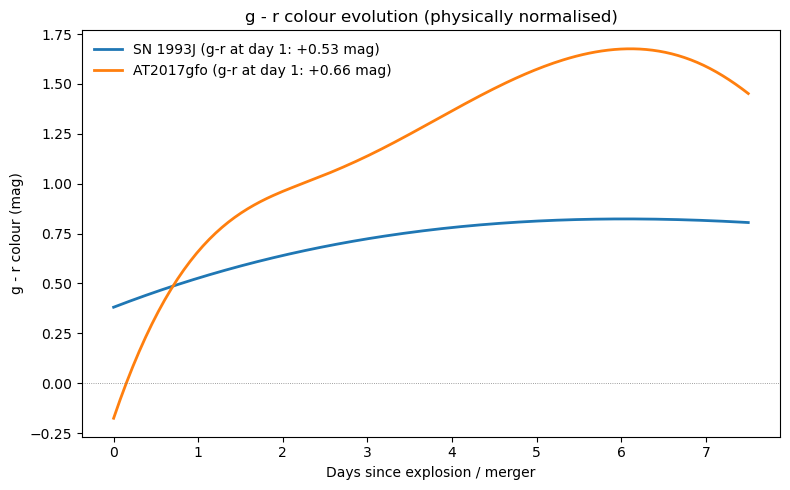

In [40]:
# g-r colour evolution from corrected splines
t_check = np.linspace(0.0, 7.5, 200)

colour_sn = spline_sn_g(t_check) - spline_sn(t_check)
colour_kn = spline_kn_g(t_check) - spline_kn(t_check)

gr_sn_day1 = (spline_sn_g(np.array([1.0])) - spline_sn(np.array([1.0])))[0]
gr_kn_day1 = (spline_kn_g(np.array([1.0])) - spline_kn(np.array([1.0])))[0]

print(f"SN 1993J  g-r at day 1: {gr_sn_day1:+.2f} mag")
print(f"AT2017gfo g-r at day 1: {gr_kn_day1:+.2f} mag")
print("Note: this absolute colour feature was investigated but not used in the")
print("final classifier. The colour rate (rate of change) is used instead.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_check, colour_sn, color="C0", linewidth=2,
        label=f"SN 1993J (g-r at day 1: {gr_sn_day1:+.2f} mag)")
ax.plot(t_check, colour_kn, color="C1", linewidth=2,
        label=f"AT2017gfo (g-r at day 1: {gr_kn_day1:+.2f} mag)")
ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("g - r colour (mag)")
ax.set_title("g - r colour evolution (physically normalised)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Colour Rate Function

The colour rate function is defined here. It computes the rate of change of g-r colour between the first two epochs where both bands are detected, expressed in magnitudes per day. A positive colour rate indicates that the source is getting redder over time, which is the physical signature of a kilonova transitioning from its blue to red ejecta component.

In [41]:
# colour_rate is defined in the 2D classifier simulation cell below.
# It is placed there to keep the function definition co-located with its use.
# Defined here as a placeholder to avoid NameErrors if cells are run out of order.

def colour_rate(m_obs_r, m_obs_g):
    """Rate of change of g-r colour between first two detected epochs (mag/day).
    Positive = getting redder. Kilonova signature.
    Returns NaN if fewer than 2 epochs detected in both bands.
    """
    valid = (~np.isnan(m_obs_r)) & (~np.isnan(m_obs_g))
    if valid.sum() < 2:
        return np.nan
    idx = np.where(valid)[0]
    t0, t1 = t_obs[idx[0]], t_obs[idx[1]]
    gr0 = m_obs_g[idx[0]] - m_obs_r[idx[0]]
    gr1 = m_obs_g[idx[1]] - m_obs_r[idx[1]]
    return (gr1 - gr0) / (t1 - t0)


## Template Colour Rate Verification

The g-r colour at both observed epochs is printed for each template, along with the resulting colour rate. This confirms that the two templates have substantially different colour rates and that the physical separation expected from the light curve analysis is present in the numerical values used by the classifier.

In [42]:
t_eval = np.array([0.0, 1.0])
gr0_sn = spline_sn_g(t_eval)[0] - spline_sn(t_eval)[0]
gr1_sn = spline_sn_g(t_eval)[1] - spline_sn(t_eval)[1]
gr0_kn = spline_kn_g(t_eval)[0] - spline_kn(t_eval)[0]
gr1_kn = spline_kn_g(t_eval)[1] - spline_kn(t_eval)[1]

print(f"SN g-r at t=0: {gr0_sn:+.3f}  at t=1: {gr1_sn:+.3f}  rate: {gr1_sn - gr0_sn:+.3f} mag/day")
print(f"KN g-r at t=0: {gr0_kn:+.3f}  at t=1: {gr1_kn:+.3f}  rate: {gr1_kn - gr0_kn:+.3f} mag/day")

SN g-r at t=0: +0.381  at t=1: +0.527  rate: +0.146 mag/day
KN g-r at t=0: -0.176  at t=1: +0.661  rate: +0.837 mag/day


## g-band Light Curve Generator

This function mirrors the r-band generator but evaluates the g-band splines instead. It applies the same distance modulus, magnitude-dependent noise model, and limiting magnitude mask. Having separate generators for each band allows independent noise realisations to be drawn, reflecting the fact that g and r observations are not perfectly correlated.

In [43]:
#  g-band light curve generator 
def generate_observed_lightcurve_g(event_type, t0, d_mpc):
    t_rest = t_obs - t0
    if event_type == "SN":
        M = spline_sn_g(t_rest)
    else:
        M = spline_kn_g(t_rest)
    M = np.array(M)
    M[t_rest < 0] = np.nan
    mu = 5 * np.log10(d_mpc * 1e6) - 5
    m_true = M + mu
    sigma = np.where(m_true <= 20, 0.1, np.where(m_true >= 21, 0.2, 0.1 + 0.1 * (m_true - 20)))
    m_obs = m_true + np.random.normal(0, sigma)
    return m_obs, sigma

## 2D Classifier Simulation

The two-feature classifier simulation is run across 100 seeds. For each event, both r-band and g-band light curves are generated and the fade rate and colour rate are computed. Events must pass both a fade rate threshold of 0.35 mag/day and a colour rate threshold of 0.10 mag/day to be classified as kilonova candidates.

In [44]:
# --- 2D classifier: fade rate + g-r colour rate ---

def colour_rate(m_obs_r, m_obs_g):
    """Rate of change of g-r colour between first two detected epochs (mag/day).
    Positive = getting redder. Kilonova signature.
    Returns NaN if fewer than 2 epochs detected in both bands.
    """
    valid = (~np.isnan(m_obs_r)) & (~np.isnan(m_obs_g))
    if valid.sum() < 2:
        return np.nan
    idx = np.where(valid)[0]
    t0, t1 = t_obs[idx[0]], t_obs[idx[1]]
    gr0 = m_obs_g[idx[0]] - m_obs_r[idx[0]]
    gr1 = m_obs_g[idx[1]] - m_obs_r[idx[1]]
    return (gr1 - gr0) / (t1 - t0)


records = []

for seed in range(1, 101):
    np.random.seed(seed)

    # --- KN ---
    kn_d = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_r, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_g, _ = generate_observed_lightcurve_g("KN", kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan

    records.append({
        "label":       1,
        "fade_rate":   fade_rate(kn_r),
        "colour_rate": colour_rate(kn_r, kn_g),
        "distance":    kn_d,
    })

    # --- 50 SNe ---
    for _ in range(50):
        d  = sample_distance()
        t0 = np.random.uniform(-1, 0)
        sn_r, _ = generate_observed_lightcurve("SN", t0, d)
        sn_g, _ = generate_observed_lightcurve_g("SN", t0, d)
        sn_r[sn_r > m_lim] = np.nan
        sn_g[sn_g > m_lim] = np.nan

        records.append({
            "label":       0,
            "fade_rate":   fade_rate(sn_r),
            "colour_rate": colour_rate(sn_r, sn_g),
            "distance":    d,
        })

events_2d = pd.DataFrame(records)

# Thresholds — consistent with 1D classifier throughout
# KN_FADE_THRESHOLD: same 0.35 mag/day used in the 1D classifier
# KN_COLOUR_RATE_THRESHOLD: set at 0.10 mag/day based on threshold sensitivity
# analysis (see threshold table cell). This value was chosen to maintain
# completeness above 86% while reducing SN false positives by ~70%.
KN_FADE_THRESHOLD        = 0.35    # mag/day — consistent throughout notebook
KN_COLOUR_RATE_THRESHOLD = 0.10   # mag/day — from threshold sensitivity analysis

events_2d["pred_2d"] = (
    (events_2d["fade_rate"]   >= KN_FADE_THRESHOLD) &
    (events_2d["colour_rate"] >= KN_COLOUR_RATE_THRESHOLD)
)

kn_mask = events_2d["label"] == 1
sn_mask = events_2d["label"] == 0

tp = (events_2d["pred_2d"] & kn_mask).sum()
fp = (events_2d["pred_2d"] & sn_mask).sum()
fn = (~events_2d["pred_2d"] & kn_mask).sum()

print(f"Colour rate threshold : {KN_COLOUR_RATE_THRESHOLD:.3f} mag/day")
print(f"TPR : {tp / kn_mask.sum():.3f}   FPR : {fp / sn_mask.sum():.4f}")
print(f"TP={tp}  FP={fp}  FN={fn}")

# Feature distribution summary
print(events_2d.groupby("label")[["fade_rate", "colour_rate"]].describe().round(3))


Colour rate threshold : 0.100 mag/day
TPR : 0.860   FPR : 0.1418
TP=86  FP=709  FN=14
      fade_rate                                                  colour_rate  \
          count   mean    std    min    25%    50%    75%    max       count   
label                                                                          
0        5000.0  0.343  0.259 -0.687  0.178  0.339  0.506  1.215      5000.0   
1         100.0  0.884  0.292  0.148  0.666  0.895  1.076  1.736       100.0   

                                                        
        mean    std    min    25%    50%    75%    max  
label                                                   
0      0.133  0.378 -1.219 -0.112  0.135  0.381  1.693  
1      0.549  0.427 -0.647  0.260  0.589  0.789  1.631  


## Template Evolution Plot

The fade rate and g-r colour evolution are plotted as functions of time for both templates on a single axes. Solid lines show fade rate and dashed lines show colour. The vertical dotted lines mark the two observed epochs at t=0 and t=1 day. This illustrates how both features evolve over the observing window.

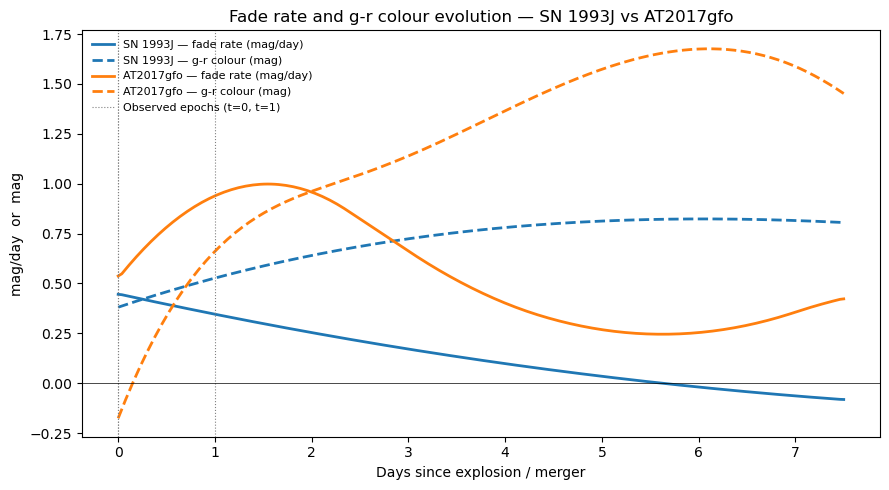

In [45]:
# --- Fade rate and g-r colour evolution for both templates ---

t_grid = np.linspace(0, 7.5, 200)
dt = t_grid[1] - t_grid[0]

# Fade rate: instantaneous gradient of r-band spline
fr_sn = np.gradient(spline_sn(t_grid), dt)
fr_kn = np.gradient(spline_kn(t_grid), dt)

# g-r colour
gr_sn = spline_sn_g(t_grid) - spline_sn(t_grid)
gr_kn = spline_kn_g(t_grid) - spline_kn(t_grid)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_grid, fr_sn, color="C0", linewidth=2, linestyle="-",  label="SN 1993J — fade rate (mag/day)")
ax.plot(t_grid, gr_sn, color="C0", linewidth=2, linestyle="--", label="SN 1993J — g-r colour (mag)")
ax.plot(t_grid, fr_kn, color="C1", linewidth=2, linestyle="-",  label="AT2017gfo — fade rate (mag/day)")
ax.plot(t_grid, gr_kn, color="C1", linewidth=2, linestyle="--", label="AT2017gfo — g-r colour (mag)")

# Mark the two observed epochs
for t_mark in [0.0, 1.0]:
    ax.axvline(t_mark, color="grey", linewidth=0.8, linestyle=":")

ax.axvline(0.0, color="grey", linewidth=0.8, linestyle=":", label="Observed epochs (t=0, t=1)")
ax.axhline(0, color="black", linewidth=0.5)

ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("mag/day  or  mag")
ax.set_title("Fade rate and g-r colour evolution — SN 1993J vs AT2017gfo")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## ROC Curve and Classification Summary: Fade Rate Only vs Hard AND Classifier

This cell compares the 1D fade rate classifier against the hard AND two-feature classifier using a ROC curve and a side-by-side bar chart.

### What the ROC Curve Is

The ROC curve shows classifier performance across every possible threshold simultaneously. For each threshold value it computes two numbers — the true positive rate (fraction of real KN correctly flagged) and the false positive rate (fraction of SN incorrectly flagged). Every possible threshold produces one point on the plot. Connecting all those points gives the full curve. A perfect classifier hugs the top left corner with AUC = 1.0. A random classifier produces a diagonal line with AUC = 0.5. The further the curve sits above the diagonal, the better the classifier.

### How the AND Score is Computed

The AND score is constructed as:
```python
and_score = np.minimum(
    fade_rate    / KN_FADE_THRESHOLD,
    colour_rate  / KN_COLOUR_RATE_THRESHOLD
)
```

Dividing each feature by its threshold normalises it so that 1.0 means exactly at the threshold, above 1.0 means passed, and below 1.0 means failed. Taking the minimum of the two means the combined score is entirely controlled by whichever feature is weakest. A fade rate of 3.0 times threshold cannot rescue a colour rate of 0.9 times threshold — the minimum is 0.9 and the event fails. Both features must independently exceed their thresholds for the event to score above 1.0. This is the AND logic encoded as a continuous number so it can be fed into the ROC curve function.

### What the Bar Chart Shows

The bar chart compares the raw classification counts for both classifiers. The fade rate only classifier flags everything above 0.35 mag/day regardless of colour. The hard AND classifier additionally requires the colour rate to exceed 0.10 mag/day. The result is fewer SN false positives because supernovae rarely pass both conditions simultaneously, but also fewer KN detected because some kilonovae caught late in their evolution fail the colour rate condition despite having a strong fade rate. This rigidity — where one weak feature kills an otherwise strong event — is the fundamental limitation of the hard AND approach and directly motivates the soft score classifier introduced in the following cell.

1D   AUC=0.918  optimal TPR=0.860  FPR=0.191
AND  AUC=0.892  optimal TPR=0.860  FPR=0.089


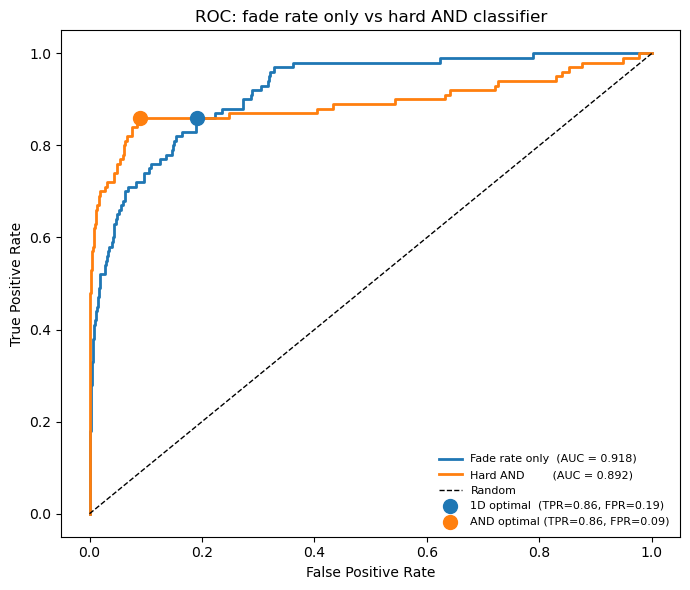

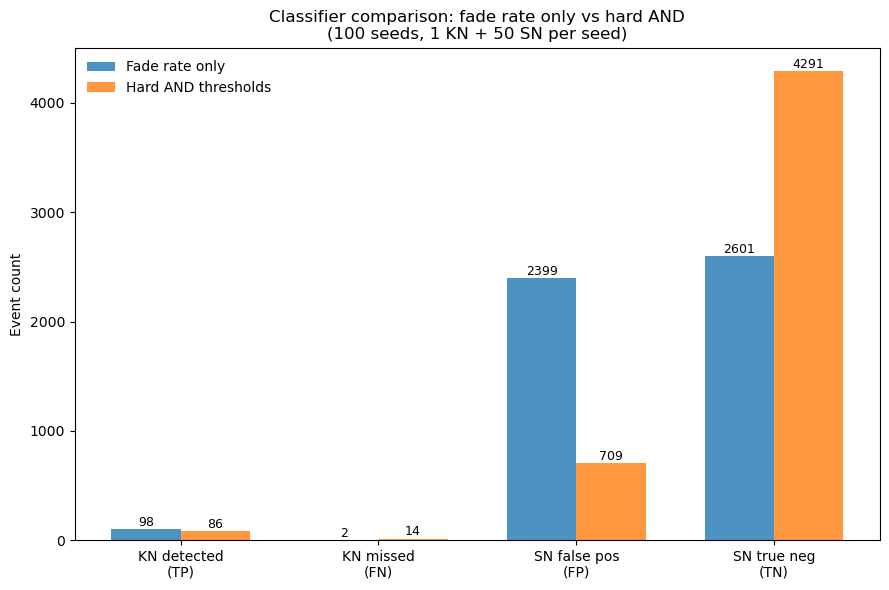

Fade rate only   precision=0.039  recall=0.980  F1=0.075
Hard AND         precision=0.108  recall=0.860  F1=0.192


In [46]:
from sklearn.metrics import roc_curve, auc

# ── Data preparation ──────────────────────────────────────────────────────────
valid  = events_2d.dropna(subset=["fade_rate", "colour_rate"]).copy()
labels = valid["label"].values
kn     = valid[valid["label"] == 1]
sn     = valid[valid["label"] == 0]

# ── ROC curves ────────────────────────────────────────────────────────────────
# 1D: fade rate alone
fpr_1d, tpr_1d, thresh_1d = roc_curve(labels, valid["fade_rate"].values)
auc_1d = auc(fpr_1d, tpr_1d)

# AND score: minimum of both threshold-normalised features
# An event only scores highly if both features pass independently######################################################
and_score = np.minimum(
    valid["fade_rate"]    / KN_FADE_THRESHOLD,
    valid["colour_rate"] / KN_COLOUR_RATE_THRESHOLD
)
#############################################################################################################################
fpr_and, tpr_and, thresh_and = roc_curve(labels, and_score.values)
auc_and = auc(fpr_and, tpr_and)

# Optimal points via Youden's J
opt_1d  = np.argmax(tpr_1d  - fpr_1d)
opt_and = np.argmax(tpr_and - fpr_and)

print(f"1D   AUC={auc_1d:.3f}  optimal TPR={tpr_1d[opt_1d]:.3f}  FPR={fpr_1d[opt_1d]:.3f}")
print(f"AND  AUC={auc_and:.3f}  optimal TPR={tpr_and[opt_and]:.3f}  FPR={fpr_and[opt_and]:.3f}")

# ── ROC plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_1d,  tpr_1d,  linewidth=2, color="C0",
        label=f"Fade rate only  (AUC = {auc_1d:.3f})")
ax.plot(fpr_and, tpr_and, linewidth=2, color="C1",
        label=f"Hard AND        (AUC = {auc_and:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.scatter([fpr_1d[opt_1d]],  [tpr_1d[opt_1d]],  s=100, color="C0", zorder=5,
           label=f"1D optimal  (TPR={tpr_1d[opt_1d]:.2f}, FPR={fpr_1d[opt_1d]:.2f})")
ax.scatter([fpr_and[opt_and]], [tpr_and[opt_and]], s=100, color="C1", zorder=5,
           label=f"AND optimal (TPR={tpr_and[opt_and]:.2f}, FPR={fpr_and[opt_and]:.2f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: fade rate only vs hard AND classifier")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# ── Bar chart ─────────────────────────────────────────────────────────────────
pred_1d_kn  = kn["fade_rate"] >= KN_FADE_THRESHOLD
pred_1d_sn  = sn["fade_rate"] >= KN_FADE_THRESHOLD
pred_and_kn = (kn["fade_rate"] >= KN_FADE_THRESHOLD) & (kn["colour_rate"] >= KN_COLOUR_RATE_THRESHOLD)
pred_and_sn = (sn["fade_rate"] >= KN_FADE_THRESHOLD) & (sn["colour_rate"] >= KN_COLOUR_RATE_THRESHOLD)

categories  = ["KN detected\n(TP)", "KN missed\n(FN)", "SN false pos\n(FP)", "SN true neg\n(TN)"]
counts_1d   = [pred_1d_kn.sum(),  (~pred_1d_kn).sum(),  pred_1d_sn.sum(),  (~pred_1d_sn).sum()]
counts_and  = [pred_and_kn.sum(), (~pred_and_kn).sum(), pred_and_sn.sum(), (~pred_and_sn).sum()]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - width/2, counts_1d,  width, label="Fade rate only",     color="C0", alpha=0.8)
b2 = ax.bar(x + width/2, counts_and, width, label="Hard AND thresholds", color="C1", alpha=0.8)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Classifier comparison: fade rate only vs hard AND\n(100 seeds, 1 KN + 50 SN per seed)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# ── Metrics ───────────────────────────────────────────────────────────────────
for name, tp, fn, fp in [
    ("Fade rate only ", counts_1d[0],  counts_1d[1],  counts_1d[2]),
    ("Hard AND       ", counts_and[0], counts_and[1], counts_and[2]),
]:
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{name}  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")

## ROC Curves, Soft Score Classifier, and Three-Way Performance Summary

This cell constructs the ROC curves, applies the soft score classifier, and produces the three-way summary bar chart comparing all three classifiers.

### What is the Soft Score and How is it Built

The soft score is a single number that combines the fade rate and the colour rate into one overall measure of how kilonova-like an event looks. Rather than asking two separate yes/no questions as the hard AND classifier does, it asks one question — is the combined signal strong enough?

The score is built using z-scoring. For any feature $x$, the z-score is:

$$z = \frac{x - \bar{x}}{\sigma_x}$$

where $\bar{x}$ is the mean of that feature across all events and $\sigma_x$ is its standard deviation. In plain English: subtract the average and divide by the spread.



1D optimal threshold : 0.564 mag/day (TPR=0.860, FPR=0.191)
2D optimal soft score: 1.428 (TPR=0.990, FPR=0.029)

Soft score classifier:
  TP=99  FP=147  FN=1
  Precision=0.402  Recall=0.990  F1=0.572


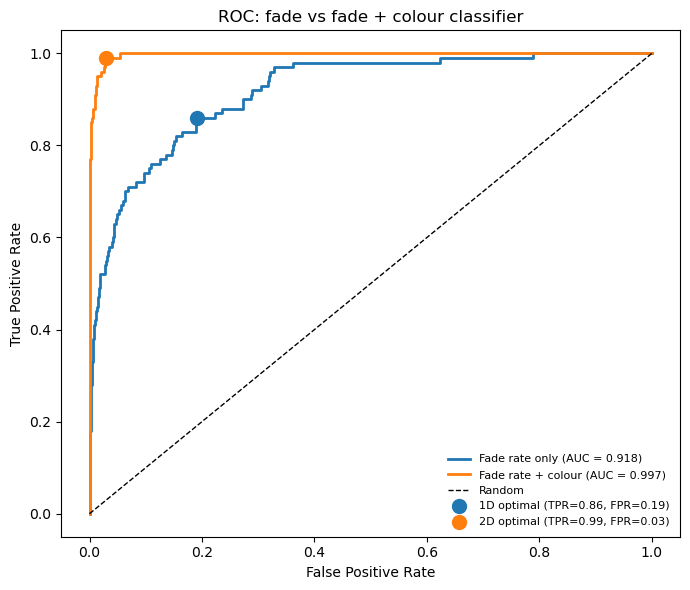

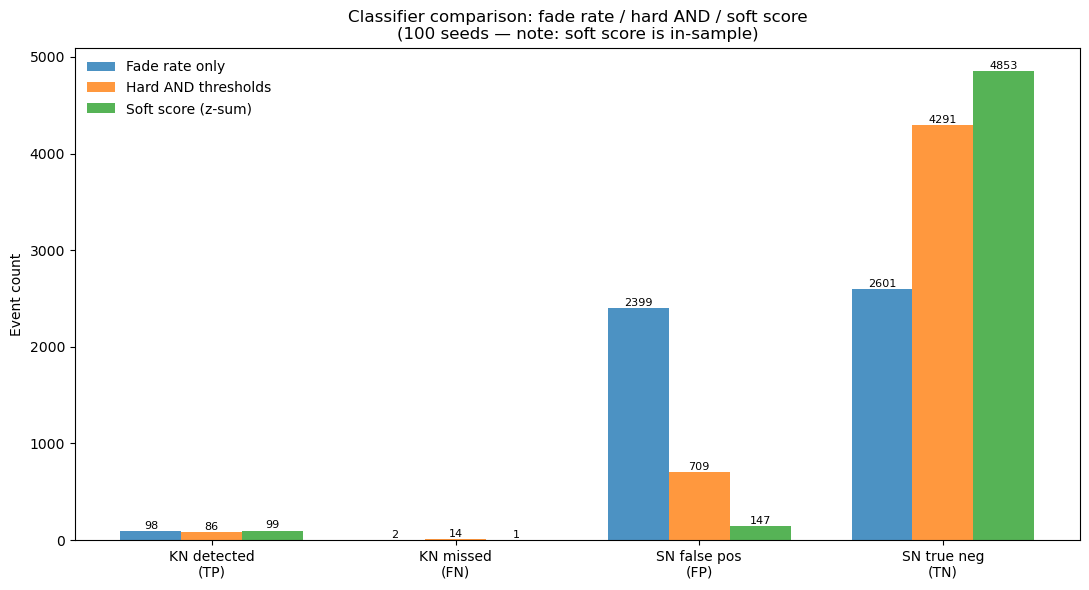

Fade rate only   precision=0.039  recall=0.980  F1=0.075
Hard AND         precision=0.108  recall=0.860  F1=0.192
Soft score       precision=0.402  recall=0.990  F1=0.572


In [47]:
from sklearn.metrics import roc_curve, auc

valid = events_2d.dropna(subset=["fade_rate", "colour_rate"])
labels = valid["label"].values

# 1D score
fpr_1d, tpr_1d, thresholds_1d = roc_curve(labels, valid["fade_rate"].values)
auc_1d = auc(fpr_1d, tpr_1d)

# 2D soft score: z-score both features and sum##########################################################
fr_norm = (valid["fade_rate"]    - valid["fade_rate"].mean())    / valid["fade_rate"].std()
cs_norm = (valid["colour_rate"] - valid["colour_rate"].mean()) / valid["colour_rate"].std()
score_2d = fr_norm + cs_norm
###############################################################################################################
fpr_2d, tpr_2d, thresholds_2d = roc_curve(labels, score_2d.values)
auc_2d = auc(fpr_2d, tpr_2d)

# --- Optimal points via Youden's J (max TPR - FPR) ---
opt_idx_1d = np.argmax(tpr_1d - fpr_1d)
opt_fpr_1d  = fpr_1d[opt_idx_1d]
opt_tpr_1d  = tpr_1d[opt_idx_1d]
opt_thresh_1d = thresholds_1d[opt_idx_1d]

opt_idx_2d = np.argmax(tpr_2d - fpr_2d)
opt_fpr_2d  = fpr_2d[opt_idx_2d]
opt_tpr_2d  = tpr_2d[opt_idx_2d]
opt_thresh_2d = thresholds_2d[opt_idx_2d]

print(f"1D optimal threshold : {opt_thresh_1d:.3f} mag/day "
      f"(TPR={opt_tpr_1d:.3f}, FPR={opt_fpr_1d:.3f})")
print(f"2D optimal soft score: {opt_thresh_2d:.3f} "
      f"(TPR={opt_tpr_2d:.3f}, FPR={opt_fpr_2d:.3f})")

# --- Apply soft score classifier ---
events_2d.loc[valid.index, "soft_score"] = score_2d.values
events_2d["pred_soft"] = events_2d["soft_score"] >= opt_thresh_2d

kn_mask = events_2d["label"] == 1
sn_mask = events_2d["label"] == 0

tp_soft = (events_2d["pred_soft"] & kn_mask).sum()
fp_soft = (events_2d["pred_soft"] & sn_mask).sum()
fn_soft = (~events_2d["pred_soft"] & kn_mask).sum()

precision_soft = tp_soft / (tp_soft + fp_soft) if (tp_soft + fp_soft) > 0 else 0
recall_soft    = tp_soft / (tp_soft + fn_soft)  if (tp_soft + fn_soft) > 0 else 0
f1_soft        = (2 * precision_soft * recall_soft / (precision_soft + recall_soft)
                  if (precision_soft + recall_soft) > 0 else 0)

print(f"\nSoft score classifier:")
print(f"  TP={tp_soft}  FP={fp_soft}  FN={fn_soft}")
print(f"  Precision={precision_soft:.3f}  Recall={recall_soft:.3f}  F1={f1_soft:.3f}")

# --- ROC plot with optimal points marked ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_1d, tpr_1d, linewidth=2, color="C0",
        label=f"Fade rate only (AUC = {auc_1d:.3f})")
ax.plot(fpr_2d, tpr_2d, linewidth=2, color="C1",
        label=f"Fade rate + colour (AUC = {auc_2d:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")

ax.scatter([opt_fpr_1d], [opt_tpr_1d], s=100, color="C0", zorder=5,
           label=f"1D optimal (TPR={opt_tpr_1d:.2f}, FPR={opt_fpr_1d:.2f})")
ax.scatter([opt_fpr_2d], [opt_tpr_2d], s=100, color="C1", zorder=5,
           label=f"2D optimal (TPR={opt_tpr_2d:.2f}, FPR={opt_fpr_2d:.2f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: fade vs fade + colour classifier")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# --- Three-way summary bar chart ---
pred_1d_kn = kn_mask & (events_2d["fade_rate"] >= KN_FADE_THRESHOLD)
pred_1d_sn = sn_mask & (events_2d["fade_rate"] >= KN_FADE_THRESHOLD)

pred_hard_kn = kn_mask & events_2d["pred_2d"]
pred_hard_sn = sn_mask & events_2d["pred_2d"]

pred_soft_kn = kn_mask & events_2d["pred_soft"]
pred_soft_sn = sn_mask & events_2d["pred_soft"]

categories = ["KN detected\n(TP)", "KN missed\n(FN)", "SN false pos\n(FP)", "SN true neg\n(TN)"]

counts_1d   = [pred_1d_kn.sum(),   (~pred_1d_kn & kn_mask).sum(),   pred_1d_sn.sum(),   (~pred_1d_sn & sn_mask).sum()]
counts_hard = [pred_hard_kn.sum(), (~pred_hard_kn & kn_mask).sum(), pred_hard_sn.sum(), (~pred_hard_sn & sn_mask).sum()]
counts_soft = [pred_soft_kn.sum(), (~pred_soft_kn & kn_mask).sum(), pred_soft_sn.sum(), (~pred_soft_sn & sn_mask).sum()]

x     = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width, counts_1d,   width, label="Fade rate only",         color="C0", alpha=0.8)
b2 = ax.bar(x,         counts_hard, width, label="Hard AND thresholds",     color="C1", alpha=0.8)
b3 = ax.bar(x + width, counts_soft, width, label="Soft score (z-sum)",      color="C2", alpha=0.8)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Classifier comparison: fade rate / hard AND / soft score\n(100 seeds — note: soft score is in-sample)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

for name, tp, fn, fp in [
    ("Fade rate only ", counts_1d[0],   counts_1d[1],   counts_1d[2]),
    ("Hard AND       ", counts_hard[0], counts_hard[1], counts_hard[2]),
    ("Soft score     ", counts_soft[0], counts_soft[1], counts_soft[2]),
]:
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{name}  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")

## 200-Seed Train/Test Split Simulation

This cell runs the full simulation across 200 independent seeds and splits
them into a training set (seeds 1-100) and a test set (seeds 101-200).
The soft score normalisation parameters and optimal threshold are computed
exclusively from the training set. They are then applied unchanged to the
test set, which the classifier has never seen. The test set performance
numbers are the honest, unbiased estimates reported in the thesis.


In [48]:
# --- 200-seed simulation with train/test split ---
# Seeds 1-100: training set (find soft score normalisation and threshold)
# Seeds 101-200: test set (honest evaluation on unseen data)
# Nothing from the test set influences the classifier setup.

records_tt = []

for seed in range(1, 201):
    np.random.seed(seed)

    kn_d  = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_r, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_g, _ = generate_observed_lightcurve_g("KN", kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan

    records_tt.append({
        "seed":        seed,
        "label":       1,
        "fade_rate":   fade_rate(kn_r),
        "colour_rate": colour_rate(kn_r, kn_g),
        "distance":    kn_d,
    })

    for _ in range(50):
        d  = sample_distance()
        t0 = np.random.uniform(-1, 0)
        sn_r, _ = generate_observed_lightcurve("SN", t0, d)
        sn_g, _ = generate_observed_lightcurve_g("SN", t0, d)
        sn_r[sn_r > m_lim] = np.nan
        sn_g[sn_g > m_lim] = np.nan

        records_tt.append({
            "seed":        seed,
            "label":       0,
            "fade_rate":   fade_rate(sn_r),
            "colour_rate": colour_rate(sn_r, sn_g),
            "distance":    d,
        })

events_tt = pd.DataFrame(records_tt)

# --- Train/test split ---
train = events_tt[events_tt["seed"] <= 100].copy()
test  = events_tt[events_tt["seed"] >  100].copy()

print(f"Training set: {len(train)} events ({(train['label']==1).sum()} KN, {(train['label']==0).sum()} SN)")
print(f"Test set:     {len(test)} events ({(test['label']==1).sum()} KN, {(test['label']==0).sum()} SN)")

# --- Compute normalisation from training set only ---
fr_mean = train["fade_rate"].mean()
fr_std  = train["fade_rate"].std()
cs_mean = train["colour_rate"].mean()
cs_std  = train["colour_rate"].std()

train_valid = train.dropna(subset=["fade_rate", "colour_rate"]).copy()
test_valid  = test.dropna(subset=["fade_rate", "colour_rate"]).copy()

train_valid["soft_score"] = (
    (train_valid["fade_rate"]    - fr_mean) / fr_std +
    (train_valid["colour_rate"] - cs_mean) / cs_std
)

# --- Find optimal threshold on training set via Youden's J ---
train_labels = train_valid["label"].values
fpr_tr, tpr_tr, thresholds_tr = roc_curve(train_labels, train_valid["soft_score"].values)
auc_train = auc(fpr_tr, tpr_tr)

opt_idx    = np.argmax(tpr_tr - fpr_tr)
opt_thresh = thresholds_tr[opt_idx]

print(f"\nTraining AUC: {auc_train:.3f}")
print(f"Optimal threshold (Youden's J, training set): {opt_thresh:.4f}")
print(f"Training TPR={tpr_tr[opt_idx]:.3f}, FPR={fpr_tr[opt_idx]:.3f}")

# --- Apply to test set using training parameters only ---
test_valid["soft_score"] = (
    (test_valid["fade_rate"]    - fr_mean) / fr_std +
    (test_valid["colour_rate"] - cs_mean) / cs_std
)

test_valid["pred_soft"] = test_valid["soft_score"] >= opt_thresh

tp_te = test_valid["pred_soft"][test_valid["label"] == 1].sum()
fp_te = test_valid["pred_soft"][test_valid["label"] == 0].sum()
fn_te = (~test_valid["pred_soft"])[test_valid["label"] == 1].sum()

precision_te = tp_te / (tp_te + fp_te) if (tp_te + fp_te) > 0 else 0
recall_te    = tp_te / (tp_te + fn_te) if (tp_te + fn_te) > 0 else 0
f1_te        = (2 * precision_te * recall_te / (precision_te + recall_te)
                if (precision_te + recall_te) > 0 else 0)

print(f"\nTest set performance (honest — unseen seeds 101-200):")
print(f"  TP={tp_te}  FP={fp_te}  FN={fn_te}")
print(f"  Precision={precision_te:.3f}  Recall={recall_te:.3f}  F1={f1_te:.3f}")

fpr_te_roc, tpr_te_roc, _ = roc_curve(test_valid["label"].values, test_valid["soft_score"].values)
auc_test = auc(fpr_te_roc, tpr_te_roc)
print(f"  Test AUC: {auc_test:.3f}")


Training set: 5100 events (100 KN, 5000 SN)
Test set:     5100 events (100 KN, 5000 SN)

Training AUC: 0.997
Optimal threshold (Youden's J, training set): 1.4285
Training TPR=0.990, FPR=0.029

Test set performance (honest — unseen seeds 101-200):
  TP=97  FP=131  FN=3
  Precision=0.425  Recall=0.970  F1=0.591
  Test AUC: 0.993


In [49]:
# --- Soft score normalisation parameters from training set ---

print("Soft score normalisation parameters (computed from training seeds 1-100)")
print("=" * 60)
print(f"Fade rate   mean : {fr_mean:.4f} mag/day")
print(f"Fade rate   std  : {fr_std:.4f} mag/day")
print(f"Colour rate mean : {cs_mean:.4f} mag/day")
print(f"Colour rate std  : {cs_std:.4f} mag/day")
print()
print(f"Optimal soft score threshold : {opt_thresh:.4f}")
print()
print("These five values are all that is needed to deploy the classifier.")
print("For any new event, the soft score is computed as:")
print()
print("  soft_score = (fade_rate - fr_mean) / fr_std")
print("             + (colour_rate - cs_mean) / cs_std")
print()
print("  If soft_score >= threshold → kilonova candidate")

Soft score normalisation parameters (computed from training seeds 1-100)
Fade rate   mean : 0.3535 mag/day
Fade rate   std  : 0.2701 mag/day
Colour rate mean : 0.1416 mag/day
Colour rate std  : 0.3831 mag/day

Optimal soft score threshold : 1.4285

These five values are all that is needed to deploy the classifier.
For any new event, the soft score is computed as:

  soft_score = (fade_rate - fr_mean) / fr_std
             + (colour_rate - cs_mean) / cs_std

  If soft_score >= threshold → kilonova candidate


## Train/Test Split Evaluation of the Soft Score Classifier

This is the most important validation cell in the notebook. Everything before this point computed the soft score parameters and threshold using the same data the classifier was then tested on, which produces optimistically biased results. This cell fixes that by using a proper train/test split — the classifier is built entirely on one set of data and evaluated on a completely separate set it has never seen.

### Why This Matters

When you find the optimal threshold by looking at all your data and then test performance on that same data, the classifier has effectively seen the exam paper before sitting the exam. It knows exactly where to draw the line because it was tuned on those specific noise realisations. A new survey with different events at different distances will not reproduce those exact noise patterns, so the in-sample performance numbers are too optimistic. The train/test split gives you the honest answer — how well does the classifier actually generalise to new data?

### How the Split Works

The simulation is extended from 100 to 200 seeds. Seeds 1 to 100 form the training set. Seeds 101 to 200 form the test set. Each seed is a completely independent survey realisation with a different kilonova and 50 different supernovae at different random distances and explosion times. The two sets are the same size — 5100 events each, 100 KN and 5000 SN — so the comparison is fair.

The key rule is that **nothing from the test set is allowed to influence the classifier setup**. The normalisation parameters — the mean and standard deviation of the fade rate and colour rate — are computed exclusively from the training set. The optimal threshold is found exclusively on the training set using Youden's J statistic. These values are then frozen and applied unchanged to the test set.

### The Z-Scoring Step

The soft score for any event is computed as:

$$S = \frac{f - \bar{f}_{\text{train}}}{\sigma_{f,\text{train}}} + \frac{c - \bar{c}_{\text{train}}}{\sigma_{c,\text{train}}}$$

where $\bar{f}_{\text{train}}$ and $\sigma_{f,\text{train}}$ are the mean and standard deviation of the fade rate computed from the **training set only**, and similarly for the colour rate. When this formula is applied to a test set event, it uses the training set statistics — not the test set statistics. This is critical. If you recomputed the means and standard deviations on the test set you would be leaking test information into the normalisation step. In code:
```python
# Compute from training set only
fr_mean = train["fade_rate"].mean()
fr_std  = train["fade_rate"].std()
cs_mean = train["colour_rate"].mean()
cs_std  = train["colour_rate"].std()

# Apply the SAME parameters to the test set
test_valid["soft_score"] = (
    (test_valid["fade_rate"]    - fr_mean) / fr_std +
    (test_valid["colour_rate"] - cs_mean) / cs_std
)
```

### What the Results Show

The training ROC and test ROC are plotted together. If the two curves sit close to each other the classifier has generalised well — the performance on unseen data matches what was observed during training. A large gap between the curves would indicate overfitting, meaning the classifier had tuned itself too closely to the specific noise patterns in the training seeds.

The bar chart compares the classification outcomes side by side for the training and test sets using the same threshold throughout. True positives, false negatives, false positives, and true negatives are shown for both. Precision, recall, and F1 are printed for both sets. The test set numbers are the ones to report in the thesis — they are the honest, unbiased estimate of how the classifier would perform on a real LSST survey it has never seen before.

Training AUC : 0.997  optimal TPR=0.990  FPR=0.029
Test AUC     : 0.993  optimal TPR=0.970  FPR=0.021


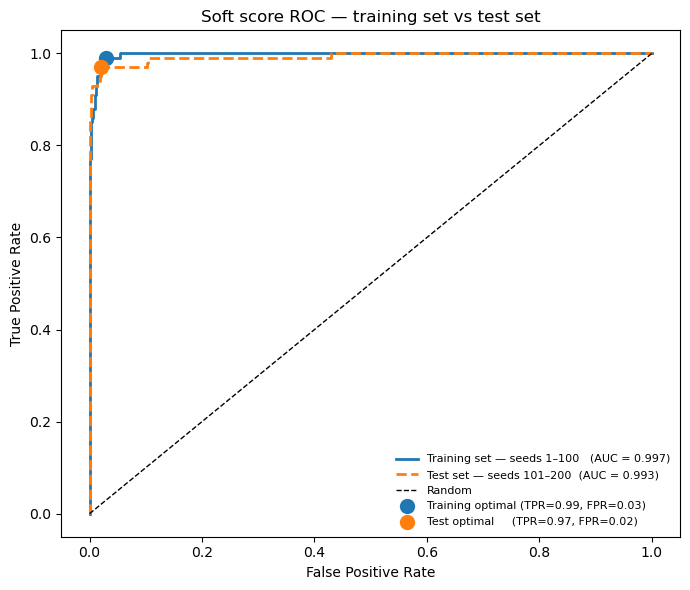

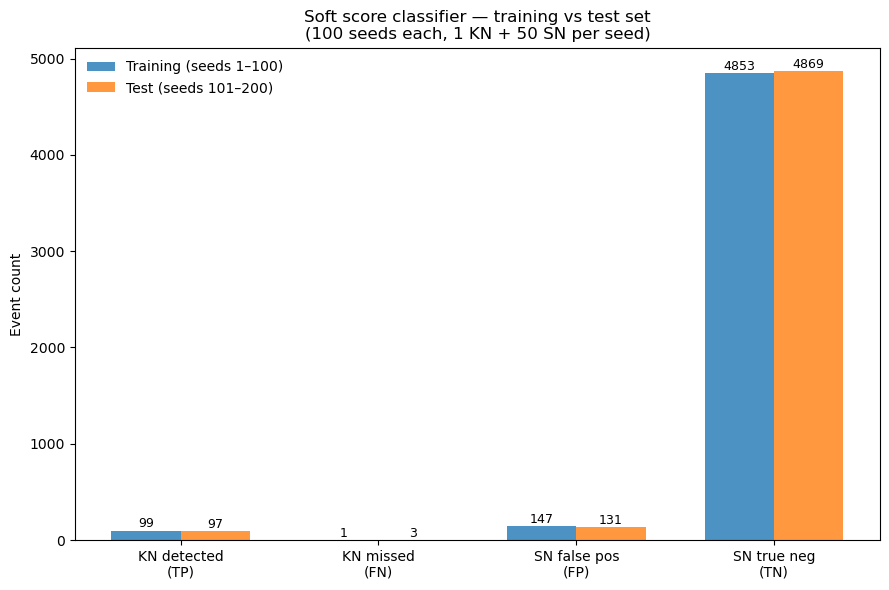

Training  TP=99  FP=147  FN=1  precision=0.402  recall=0.990  F1=0.572
Test      TP=97  FP=131  FN=3  precision=0.425  recall=0.970  F1=0.591


In [50]:
# --- ROC and bar chart: training set vs test set ---

from sklearn.metrics import roc_curve, auc

# --- ROC curves ---
fpr_tr, tpr_tr, _ = roc_curve(train_valid["label"].values, train_valid["soft_score"].values)
fpr_te, tpr_te, _ = roc_curve(test_valid["label"].values,  test_valid["soft_score"].values)
auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)

# Optimal points
opt_tr = np.argmax(tpr_tr - fpr_tr)
opt_te = np.argmax(tpr_te - fpr_te)

print(f"Training AUC : {auc_tr:.3f}  optimal TPR={tpr_tr[opt_tr]:.3f}  FPR={fpr_tr[opt_tr]:.3f}")
print(f"Test AUC     : {auc_te:.3f}  optimal TPR={tpr_te[opt_te]:.3f}  FPR={fpr_te[opt_te]:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_tr, tpr_tr, linewidth=2, color="C0",
        label=f"Training set — seeds 1–100   (AUC = {auc_tr:.3f})")
ax.plot(fpr_te, tpr_te, linewidth=2, color="C1", linestyle="--",
        label=f"Test set — seeds 101–200  (AUC = {auc_te:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.scatter([fpr_tr[opt_tr]], [tpr_tr[opt_tr]], s=100, color="C0", zorder=5,
           label=f"Training optimal (TPR={tpr_tr[opt_tr]:.2f}, FPR={fpr_tr[opt_tr]:.2f})")
ax.scatter([fpr_te[opt_te]], [tpr_te[opt_te]], s=100, color="C1", zorder=5,
           label=f"Test optimal     (TPR={tpr_te[opt_te]:.2f}, FPR={fpr_te[opt_te]:.2f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Soft score ROC — training set vs test set")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# --- Bar chart: training vs test ---
# Apply threshold (found on training set) to both sets
train_valid["pred_soft"] = train_valid["soft_score"] >= opt_thresh
test_valid["pred_soft"]  = test_valid["soft_score"]  >= opt_thresh

def get_counts(df):
    kn = df[df["label"] == 1]
    sn = df[df["label"] == 0]
    tp = kn["pred_soft"].sum()
    fn = (~kn["pred_soft"]).sum()
    fp = sn["pred_soft"].sum()
    tn = (~sn["pred_soft"]).sum()
    return [tp, fn, fp, tn]

counts_train = get_counts(train_valid)
counts_test  = get_counts(test_valid)

categories = ["KN detected\n(TP)", "KN missed\n(FN)", "SN false pos\n(FP)", "SN true neg\n(TN)"]
x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - width/2, counts_train, width, label="Training (seeds 1–100)",  color="C0", alpha=0.8)
b2 = ax.bar(x + width/2, counts_test,  width, label="Test (seeds 101–200)",     color="C1", alpha=0.8)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Soft score classifier — training vs test set\n(100 seeds each, 1 KN + 50 SN per seed)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Print metrics for both
for name, counts in [("Training", counts_train), ("Test    ", counts_test)]:
    tp, fn, fp, tn = counts
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{name}  TP={tp}  FP={fp}  FN={fn}  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")

## Deployment: Pre-Trained Soft Score on Unseen Seeds

This cell is the final validation of the classifier. It applies the soft score with completely fixed pre-trained parameters to a third batch of survey realisations that were never involved in any part of the classifier development. No learning takes place here — the four normalisation parameters and the threshold are all imported directly from the training set and applied without modification.

The purpose is to simulate real-world deployment. In practice, a classifier trained on simulated data would be applied to new LSST alerts as they arrive, with no opportunity to retune parameters. This cell recreates that scenario exactly. The deployment parameters are:
```python
DEPLOY_FR_MEAN   = fr_mean      # mean fade rate from training seeds 1-100
DEPLOY_FR_STD    = fr_std       # std fade rate from training seeds 1-100
DEPLOY_CS_MEAN   = cs_mean      # mean colour rate from training seeds 1-100
DEPLOY_CS_STD    = cs_std       # std colour rate from training seeds 1-100
DEPLOY_THRESHOLD = 1.4285       # optimal threshold from Youden's J on training set
```

For each new event the soft score is computed as:

$$S = \frac{f - \bar{f}_{\text{train}}}{\sigma_{f,\text{train}}} + \frac{c - \bar{c}_{\text{train}}}{\sigma_{c,\text{train}}}$$

If $S \geq 1.4285$ the event is flagged as a kilonova candidate. This is a single arithmetic operation applied independently to each new alert with no reference to any other event in the deployment set.

The ROC curve plots the deployment set alongside the training and test ROC curves from the previous cell. If all three curves sit close together the classifier has genuinely learned a stable physical signal rather than memorising noise patterns from specific seeds. The bar chart shows the raw classification counts for the deployment set alone. Precision, recall, and F1 are printed for direct comparison against the training and test set results reported earlier.

Deployment parameters (fixed from training set):
  Fade rate   mean : 0.3535 mag/day
  Fade rate   std  : 0.2701 mag/day
  Colour rate mean : 0.1416 mag/day
  Colour rate std  : 0.3831 mag/day
  Threshold        : 1.4285

Deployment results (seeds 201-300, never seen before):
  TP=97  FP=135  FN=3  TN=4865
  Precision=0.418  Recall=0.970  F1=0.584


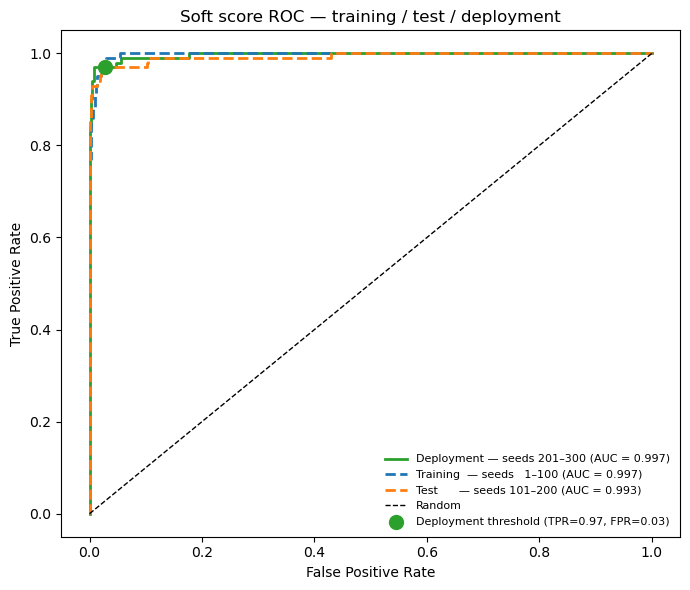

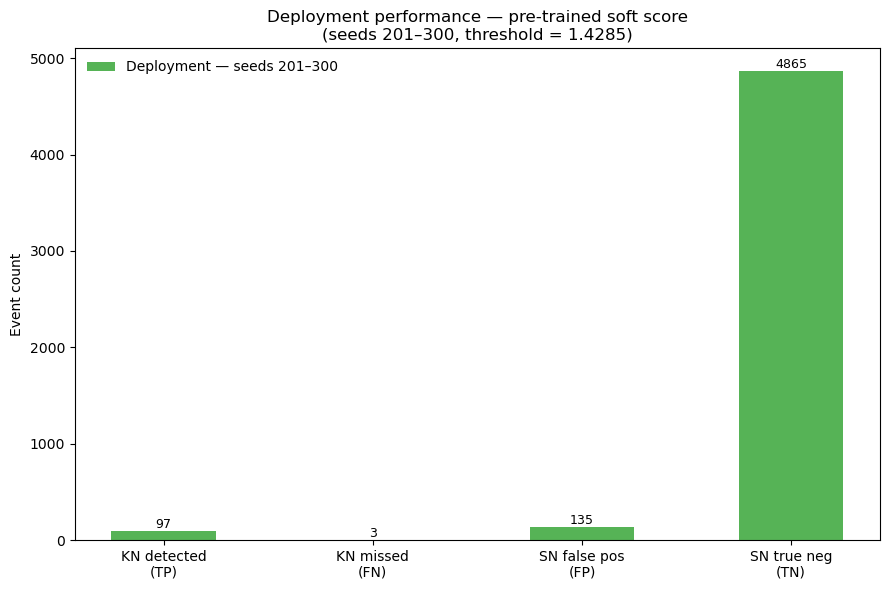

In [51]:
# --- Pure deployment cell: apply pre-trained soft score to new seeds 201-300 ---
# No learning. No threshold tuning. Parameters fixed from training set (seeds 1-100).

DEPLOY_FR_MEAN   = 0.3535   # fade rate mean (mag/day) — training seeds 1-100
DEPLOY_FR_STD    = 0.2701   # fade rate std  (mag/day) — training seeds 1-100
DEPLOY_CS_MEAN   = 0.1416   # colour rate mean (mag/day) — training seeds 1-100
DEPLOY_CS_STD    = 0.3831   # colour rate std  (mag/day) — training seeds 1-100
DEPLOY_THRESHOLD = 1.4285   # optimal threshold from Youden's J — training seeds 1-100

print("Deployment parameters (fixed from training set):")
print(f"  Fade rate   mean : {DEPLOY_FR_MEAN:.4f} mag/day")
print(f"  Fade rate   std  : {DEPLOY_FR_STD:.4f} mag/day")
print(f"  Colour rate mean : {DEPLOY_CS_MEAN:.4f} mag/day")
print(f"  Colour rate std  : {DEPLOY_CS_STD:.4f} mag/day")
print(f"  Threshold        : {DEPLOY_THRESHOLD:.4f}")
print()

# --- Generate new events: seeds 201-300 ---
deploy_records = []

for seed in range(301, 401):
    np.random.seed(seed)

    kn_d  = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_r, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_g, _ = generate_observed_lightcurve_g("KN", kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan

    deploy_records.append({
        "seed":        seed,
        "label":       1,
        "fade_rate":   fade_rate(kn_r),
        "colour_rate": colour_rate(kn_r, kn_g),
        "distance":    kn_d,
    })

    for _ in range(50):
        d  = sample_distance()
        t0 = np.random.uniform(-1, 0)
        sn_r, _ = generate_observed_lightcurve("SN", t0, d)
        sn_g, _ = generate_observed_lightcurve_g("SN", t0, d)
        sn_r[sn_r > m_lim] = np.nan
        sn_g[sn_g > m_lim] = np.nan

        deploy_records.append({
            "seed":        seed,
            "label":       0,
            "fade_rate":   fade_rate(sn_r),
            "colour_rate": colour_rate(sn_r, sn_g),
            "distance":    d,
        })

deploy_df    = pd.DataFrame(deploy_records)
deploy_valid = deploy_df.dropna(subset=["fade_rate", "colour_rate"]).copy()

# --- Apply pre-trained soft score ---
deploy_valid["soft_score"] = (
    (deploy_valid["fade_rate"]    - DEPLOY_FR_MEAN) / DEPLOY_FR_STD +
    (deploy_valid["colour_rate"] - DEPLOY_CS_MEAN) / DEPLOY_CS_STD
)
deploy_valid["pred"] = deploy_valid["soft_score"] >= DEPLOY_THRESHOLD

# --- Metrics ---
kn_dep = deploy_valid[deploy_valid["label"] == 1]
sn_dep = deploy_valid[deploy_valid["label"] == 0]

tp = kn_dep["pred"].sum()
fn = (~kn_dep["pred"]).sum()
fp = sn_dep["pred"].sum()
tn = (~sn_dep["pred"]).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Deployment results (seeds 201-300, never seen before):")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")

# --- ROC curve ---
from sklearn.metrics import roc_curve, auc

fpr_dep, tpr_dep, _ = roc_curve(deploy_valid["label"].values,
                                 deploy_valid["soft_score"].values)
auc_dep = auc(fpr_dep, tpr_dep)

# Mark deployment threshold on ROC
dep_tpr = recall
dep_fpr = fp / len(sn_dep)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_dep, tpr_dep, linewidth=2, color="C2",
        label=f"Deployment — seeds 201–300 (AUC = {auc_dep:.3f})")
ax.plot(fpr_tr, tpr_tr, linewidth=2, color="C0", linestyle="--",
        label=f"Training  — seeds   1–100 (AUC = {auc_train:.3f})")
ax.plot(fpr_te, tpr_te, linewidth=2, color="C1", linestyle="--",
        label=f"Test      — seeds 101–200 (AUC = {auc_test:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.scatter([dep_fpr], [dep_tpr], s=100, color="C2", zorder=5,
           label=f"Deployment threshold (TPR={dep_tpr:.2f}, FPR={dep_fpr:.2f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Soft score ROC — training / test / deployment")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# --- Bar chart ---
categories = ["KN detected\n(TP)", "KN missed\n(FN)",
              "SN false pos\n(FP)", "SN true neg\n(TN)"]
counts_dep = [tp, fn, fp, tn]

x     = np.arange(len(categories))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(x, counts_dep, width, color="C2", alpha=0.8,
              label="Deployment — seeds 201–300")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Deployment performance — pre-trained soft score\n"
             f"(seeds 201–300, threshold = {DEPLOY_THRESHOLD})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

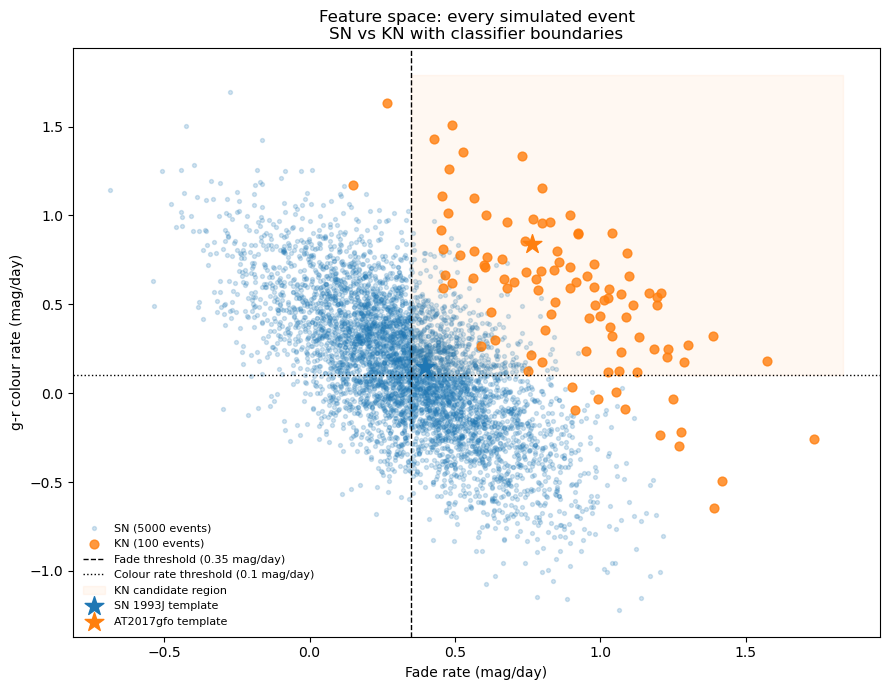

Events in KN candidate region (top right):
  KN: 86 / 100
  SN: 709 / 5000


In [52]:
# --- Scatter plot: fade rate vs g-r colour rate for every simulated event ---

valid = events_2d.dropna(subset=["fade_rate", "colour_rate"])
kn_ev = valid[valid["label"] == 1]
sn_ev = valid[valid["label"] == 0]

fig, ax = plt.subplots(figsize=(9, 7))

# Plot every SN point
ax.scatter(sn_ev["fade_rate"], sn_ev["colour_rate"],
           s=8, alpha=0.2, color="C0", label=f"SN ({len(sn_ev)} events)")

# Plot every KN point
ax.scatter(kn_ev["fade_rate"], kn_ev["colour_rate"],
           s=40, alpha=0.8, color="C1", label=f"KN ({len(kn_ev)} events)")

# Threshold lines
ax.axvline(KN_FADE_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"Fade threshold ({KN_FADE_THRESHOLD} mag/day)")
ax.axhline(KN_COLOUR_RATE_THRESHOLD, color="black", linestyle=":", linewidth=1,
           label=f"Colour rate threshold ({KN_COLOUR_RATE_THRESHOLD} mag/day)")

# Shade the classification region — top right is KN candidate zone
ax.fill_between(
    [KN_FADE_THRESHOLD, valid["fade_rate"].max() + 0.1],
    KN_COLOUR_RATE_THRESHOLD,
    valid["colour_rate"].max() + 0.1,
    alpha=0.05, color="C1", label="KN candidate region"
)

# Template positions at t=0 and t=1
t_eval = np.array([0.0, 1.0])
fr_sn_template = float(np.gradient(spline_sn(t_eval), 1.0)[1])
fr_kn_template = float(np.gradient(spline_kn(t_eval), 1.0)[1])
gr0_sn = spline_sn_g(t_eval)[0] - spline_sn(t_eval)[0]
gr1_sn = spline_sn_g(t_eval)[1] - spline_sn(t_eval)[1]
gr0_kn = spline_kn_g(t_eval)[0] - spline_kn(t_eval)[0]
gr1_kn = spline_kn_g(t_eval)[1] - spline_kn(t_eval)[1]
cr_sn_template = gr1_sn - gr0_sn
cr_kn_template = gr1_kn - gr0_kn

ax.scatter([fr_sn_template], [cr_sn_template], s=200, color="C0",
           marker="*", zorder=6, label="SN 1993J template")
ax.scatter([fr_kn_template], [cr_kn_template], s=200, color="C1",
           marker="*", zorder=6, label="AT2017gfo template")

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title("Feature space: every simulated event\nSN vs KN with classifier boundaries")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Events in KN candidate region (top right):")
print(f"  KN: {((kn_ev['fade_rate'] >= KN_FADE_THRESHOLD) & (kn_ev['colour_rate'] >= KN_COLOUR_RATE_THRESHOLD)).sum()} / {len(kn_ev)}")
print(f"  SN: {((sn_ev['fade_rate'] >= KN_FADE_THRESHOLD) & (sn_ev['colour_rate'] >= KN_COLOUR_RATE_THRESHOLD)).sum()} / {len(sn_ev)}")

kNN classifier (k=5, distance weighting):
  TP=83  FP=11  FN=17  TN=4989
  Precision=0.883  Recall=0.830  F1=0.856


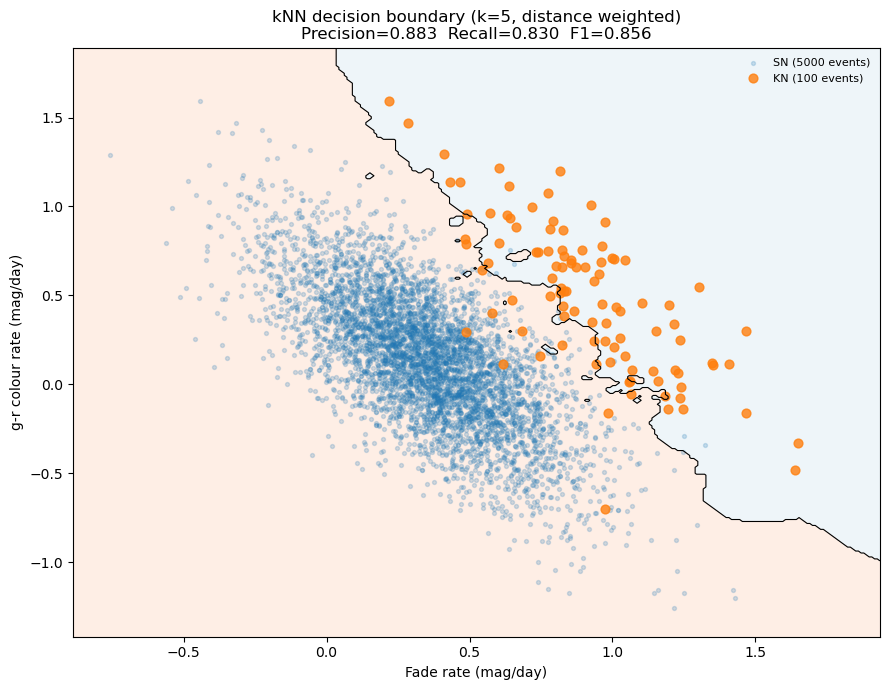

In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# --- Prepare training data (seeds 1-100) ---

X_train = train_valid[["fade_rate", "colour_rate"]].values
y_train = train_valid["label"].values

X_test = test_valid[["fade_rate", "colour_rate"]].values
y_test = test_valid["label"].values

# --- Fit kNN: k=5, distance weighting ---
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train, y_train)

# --- Predict on test set ---
y_pred = knn.predict(X_test)

# --- Metrics ---
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"kNN classifier (k=5, distance weighting):")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")

# --- Decision boundary plot ---
# Create a grid covering the feature space
fr_min, fr_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
cr_min, cr_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2

xx, yy = np.meshgrid(np.linspace(fr_min, fr_max, 300),
                     np.linspace(cr_min, cr_max, 300))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))

# Decision boundary
ax.contourf(xx, yy, Z, alpha=0.15, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors="black", linewidths=0.8, levels=[0.5])

# All test set events
kn_test = test_valid[test_valid["label"] == 1]
sn_test = test_valid[test_valid["label"] == 0]

ax.scatter(sn_test["fade_rate"], sn_test["colour_rate"],
           s=8, alpha=0.2, color="C0", label=f"SN ({len(sn_test)} events)")
ax.scatter(kn_test["fade_rate"], kn_test["colour_rate"],
           s=40, alpha=0.8, color="C1", label=f"KN ({len(kn_test)} events)")

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title(f"kNN decision boundary (k=5, distance weighted)\n"
             f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

kNN classifier (k=5, distance weighted, z-scored):
  TP=85  FP=13  FN=15  TN=4987
  Precision=0.867  Recall=0.850  F1=0.859


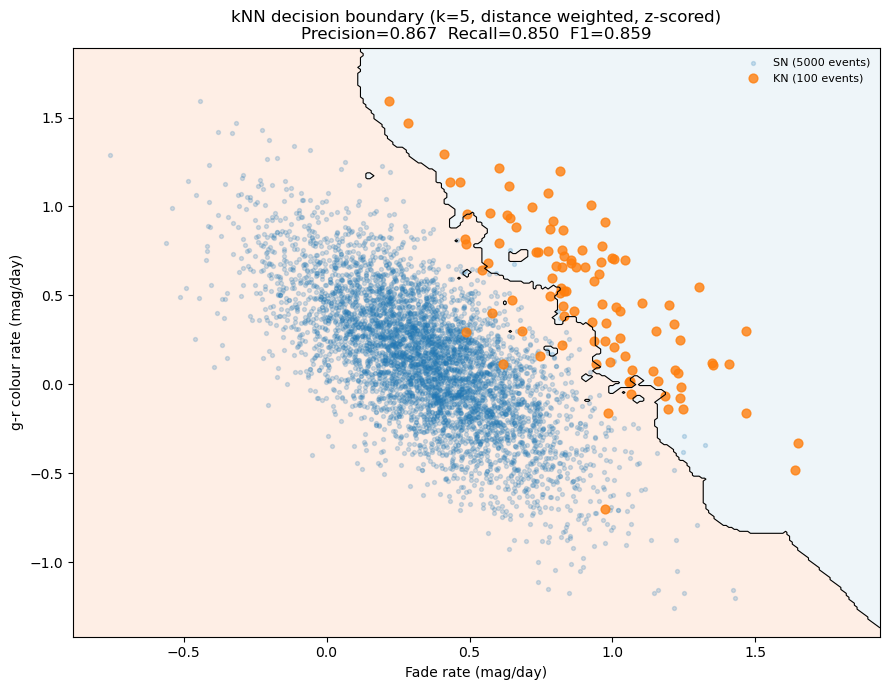

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# --- Feature matrices from existing train/test split ---
X_train = train_valid[["fade_rate", "colour_rate"]].values
y_train = train_valid["label"].values

X_test = test_valid[["fade_rate", "colour_rate"]].values
y_test = test_valid["label"].values

# --- Z-score using training set statistics only ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # use training mean/std, not test

# --- Fit kNN: k=5, distance weighting, on z-scored features --- ###################
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train_scaled, y_train)
####################################################################################
# --- Predict on test set ---
y_pred = knn.predict(X_test_scaled)

# --- Metrics ---
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"kNN classifier (k=5, distance weighted, z-scored):")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")

# --- Decision boundary plot ---
fr_min, fr_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
cr_min, cr_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2

xx, yy = np.meshgrid(np.linspace(fr_min, fr_max, 300),
                     np.linspace(cr_min, cr_max, 300))

grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = knn.predict(grid_scaled).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))

ax.contourf(xx, yy, Z, alpha=0.15, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors="black", linewidths=0.8, levels=[0.5])

kn_test = test_valid[test_valid["label"] == 1]
sn_test = test_valid[test_valid["label"] == 0]

ax.scatter(sn_test["fade_rate"], sn_test["colour_rate"],
           s=8, alpha=0.2, color="C0", label=f"SN ({len(sn_test)} events)")
ax.scatter(kn_test["fade_rate"], kn_test["colour_rate"],
           s=40, alpha=0.8, color="C1", label=f"KN ({len(kn_test)} events)")

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title(f"kNN decision boundary (k=5, distance weighted, z-scored)\n"
             f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Metric                 Soft Score    kNN (k=5)     Winner
----------------------------------------------------------
TP                             97           85
FP                            131           13
FN                              3           15
TN                           4869         4987
----------------------------------------------------------
Precision                   0.425        0.867        kNN
Recall                      0.970        0.850       Soft
F1                          0.591        0.859        kNN
----------------------------------------------------------


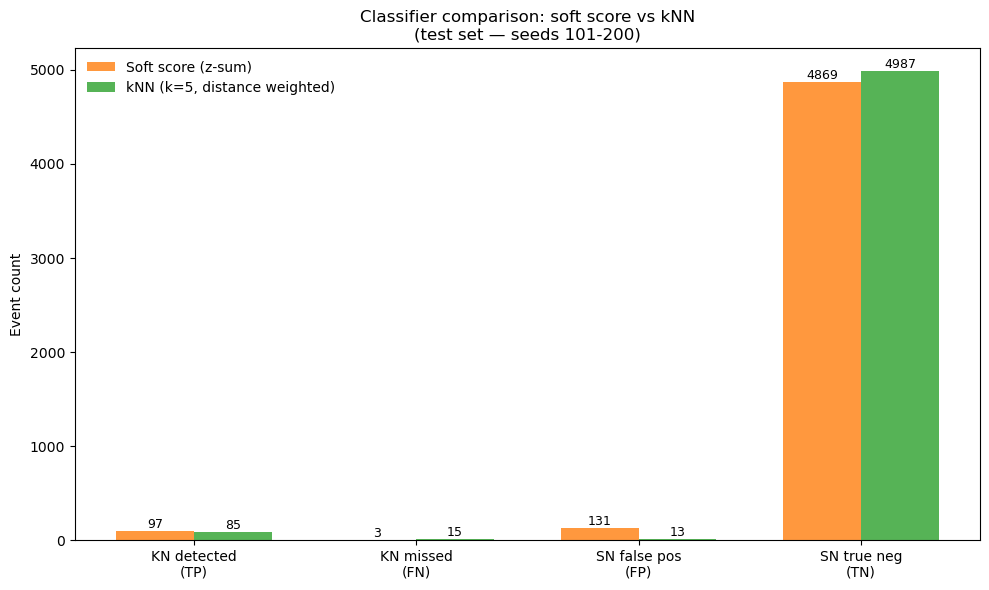

In [55]:
# --- Comparison table: soft score vs kNN ---

# Soft score test set results
soft_tp = tp_te
soft_fp = fp_te
soft_fn = fn_te
soft_tn = len(test_valid) - tp_te - fp_te - fn_te

soft_precision = soft_tp / (soft_tp + soft_fp) if (soft_tp + soft_fp) > 0 else 0
soft_recall    = soft_tp / (soft_tp + soft_fn) if (soft_tp + soft_fn) > 0 else 0
soft_f1        = 2 * soft_precision * soft_recall / (soft_precision + soft_recall) if (soft_precision + soft_recall) > 0 else 0

# kNN test set results
knn_precision = precision
knn_recall    = recall
knn_f1        = f1

# --- Print table ---
print(f"{'Metric':<20} {'Soft Score':>12} {'kNN (k=5)':>12} {'Winner':>10}")
print("-" * 58)
print(f"{'TP':<20} {soft_tp:>12} {tp:>12}")
print(f"{'FP':<20} {soft_fp:>12} {fp:>12}")
print(f"{'FN':<20} {soft_fn:>12} {fn:>12}")
print(f"{'TN':<20} {soft_tn:>12} {tn:>12}")
print("-" * 58)
print(f"{'Precision':<20} {soft_precision:>12.3f} {knn_precision:>12.3f} {'kNN' if knn_precision > soft_precision else 'Soft':>10}")
print(f"{'Recall':<20} {soft_recall:>12.3f} {knn_recall:>12.3f} {'kNN' if knn_recall > soft_recall else 'Soft':>10}")
print(f"{'F1':<20} {soft_f1:>12.3f} {knn_f1:>12.3f} {'kNN' if knn_f1 > soft_f1 else 'Soft':>10}")
print("-" * 58)

# --- Bar chart: TP FP FN TN side by side ---
categories = ["KN detected\n(TP)", "KN missed\n(FN)", "SN false pos\n(FP)", "SN true neg\n(TN)"]

counts_soft = [soft_tp, soft_fn, soft_fp, soft_tn]
counts_knn  = [tp,      fn,      fp,      tn]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, counts_soft, width, label="Soft score (z-sum)", color="C1", alpha=0.8)
b2 = ax.bar(x + width/2, counts_knn,  width, label="kNN (k=5, distance weighted)", color="C2", alpha=0.8)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Classifier comparison: soft score vs kNN\n(test set — seeds 101-200)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Linear Discriminant Analysis:
  TP=86  FP=9  FN=14  TN=4991
  Precision=0.905  Recall=0.860  F1=0.882

Decision boundary:
  20.136 × fade_rate + 12.242 × colour_rate + -20.441 = 0


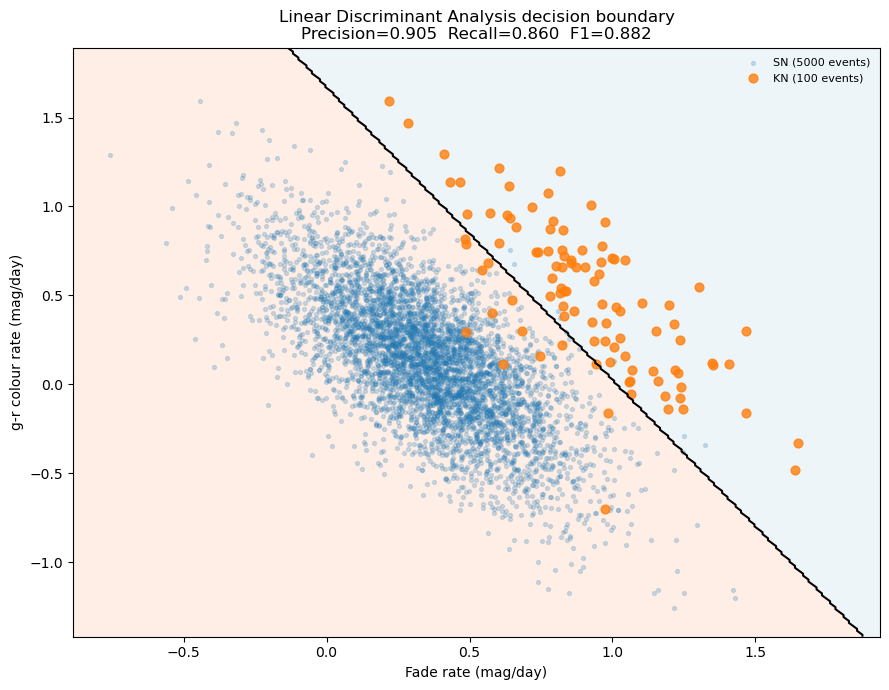

In [56]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- Feature matrices ---
X_train = train_valid[["fade_rate", "colour_rate"]].values
y_train = train_valid["label"].values
X_test  = test_valid[["fade_rate", "colour_rate"]].values
y_test  = test_valid["label"].values

# --- Fit LDA ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

# --- Metrics ---
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Linear Discriminant Analysis:")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")

# Print the decision boundary equation
coef = lda.coef_[0]
intercept = lda.intercept_[0]
print(f"\nDecision boundary:")
print(f"  {coef[0]:.3f} × fade_rate + {coef[1]:.3f} × colour_rate + {intercept:.3f} = 0")

# --- Plot ---
fr_min, fr_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
cr_min, cr_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2

xx, yy = np.meshgrid(np.linspace(fr_min, fr_max, 300),
                     np.linspace(cr_min, cr_max, 300))

Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))

ax.contourf(xx, yy, Z, alpha=0.15, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors="black", linewidths=1.5, levels=[0.5])

kn_test = test_valid[test_valid["label"] == 1]
sn_test = test_valid[test_valid["label"] == 0]

ax.scatter(sn_test["fade_rate"], sn_test["colour_rate"],
           s=8, alpha=0.2, color="C0", label=f"SN ({len(sn_test)} events)")
ax.scatter(kn_test["fade_rate"], kn_test["colour_rate"],
           s=40, alpha=0.8, color="C1", label=f"KN ({len(kn_test)} events)")

ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("g-r colour rate (mag/day)")
ax.set_title(f"Linear Discriminant Analysis decision boundary\n"
             f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Metric                 Soft Score    kNN (k=5)          LDA
------------------------------------------------------------
KN detected (TP)               97           85           86
KN missed (FN)                  3           15           14
SN false pos (FP)             131           13            9
SN true neg (TN)             4869         4987         4991
------------------------------------------------------------
Precision                   0.425        0.867        0.905
Recall                      0.970        0.850        0.860
F1                          0.591        0.859        0.882
------------------------------------------------------------


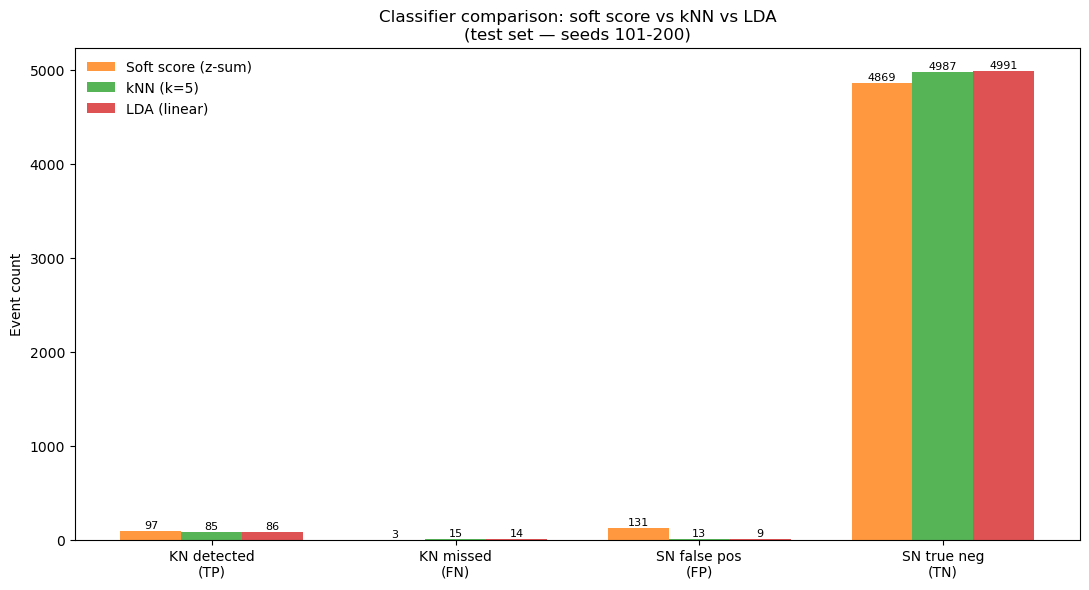

In [57]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# --- Feature matrices ---
X_train = train_valid[["fade_rate", "colour_rate"]].values
y_train = train_valid["label"].values
X_test  = test_valid[["fade_rate", "colour_rate"]].values
y_test  = test_valid["label"].values

# Z-score for kNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Fit all three classifiers ---
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

# Soft score predictions
test_valid["soft_score"] = (
    (test_valid["fade_rate"]    - fr_mean) / fr_std +
    (test_valid["colour_rate"] - cs_mean) / cs_std
)
y_pred_soft = (test_valid["soft_score"] >= opt_thresh).values

# --- Compute metrics for all three ---
def get_metrics(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return tp, fp, fn, tn, precision, recall, f1

soft_tp, soft_fp, soft_fn, soft_tn, soft_prec, soft_rec, soft_f1 = get_metrics(y_test, y_pred_soft)
knn_tp,  knn_fp,  knn_fn,  knn_tn,  knn_prec,  knn_rec,  knn_f1  = get_metrics(y_test, y_pred_knn)
lda_tp,  lda_fp,  lda_fn,  lda_tn,  lda_prec,  lda_rec,  lda_f1  = get_metrics(y_test, y_pred_lda)

# --- Print table ---
print(f"{'Metric':<20} {'Soft Score':>12} {'kNN (k=5)':>12} {'LDA':>12}")
print("-" * 60)
print(f"{'KN detected (TP)':<20} {soft_tp:>12} {knn_tp:>12} {lda_tp:>12}")
print(f"{'KN missed (FN)':<20} {soft_fn:>12} {knn_fn:>12} {lda_fn:>12}")
print(f"{'SN false pos (FP)':<20} {soft_fp:>12} {knn_fp:>12} {lda_fp:>12}")
print(f"{'SN true neg (TN)':<20} {soft_tn:>12} {knn_tn:>12} {lda_tn:>12}")
print("-" * 60)
print(f"{'Precision':<20} {soft_prec:>12.3f} {knn_prec:>12.3f} {lda_prec:>12.3f}")
print(f"{'Recall':<20} {soft_rec:>12.3f} {knn_rec:>12.3f} {lda_rec:>12.3f}")
print(f"{'F1':<20} {soft_f1:>12.3f} {knn_f1:>12.3f} {lda_f1:>12.3f}")
print("-" * 60)

# --- Bar chart ---
categories  = ["KN detected\n(TP)", "KN missed\n(FN)", "SN false pos\n(FP)", "SN true neg\n(TN)"]
counts_soft = [soft_tp, soft_fn, soft_fp, soft_tn]
counts_knn  = [knn_tp,  knn_fn,  knn_fp,  knn_tn]
counts_lda  = [lda_tp,  lda_fn,  lda_fp,  lda_tn]

x     = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width, counts_soft, width, label="Soft score (z-sum)", color="C1", alpha=0.8)
b2 = ax.bar(x,         counts_knn,  width, label="kNN (k=5)",          color="C2", alpha=0.8)
b3 = ax.bar(x + width, counts_lda,  width, label="LDA (linear)",       color="C3", alpha=0.8)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Event count")
ax.set_title("Classifier comparison: soft score vs kNN vs LDA\n(test set — seeds 101-200)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [58]:
# Phase sweep on AT2017gfo spline template
# Simulate observations at a range of starting phases and compute features

t_start_vals = np.linspace(0.0, 7.0, 50)  # start epoch from 0 to 7 days post merger
dt = 1.0  # 1 day baseline between epochs

records_kn = []

for t1 in t_start_vals:
    t2 = t1 + dt

    # r-band
    r1 = spline_kn(np.array([t1]))[0]
    r2 = spline_kn(np.array([t2]))[0]
    fade_rate = (r2 - r1) / dt

    # g-band
    g1 = spline_kn_g(np.array([t1]))[0]
    g2 = spline_kn_g(np.array([t2]))[0]

    gr1 = g1 - r1
    gr2 = g2 - r2
    colour_rate = (gr2 - gr1) / dt

    soft_score = (fade_rate - DEPLOY_FR_MEAN) / DEPLOY_FR_STD + \
                 (colour_rate - DEPLOY_CS_MEAN) / DEPLOY_CS_STD

    records_kn.append({
        'phase':        t1,
        'fade_rate':    fade_rate,
        'colour_rate':  colour_rate,
        'soft_score':   soft_score,
        'kn_candidate': soft_score > DEPLOY_THRESHOLD
    })

sweep_kn = pd.DataFrame(records_kn)
detected = sweep_kn[sweep_kn['kn_candidate']]
print(f'Phases evaluated: {len(sweep_kn)}')
print(f'Detected as KN candidate: {len(detected)}')
print(f'Detection window: {detected["phase"].min():.2f} to {detected["phase"].max():.2f} days post merger')

Phases evaluated: 50
Detected as KN candidate: 17
Detection window: 0.00 to 2.29 days post merger


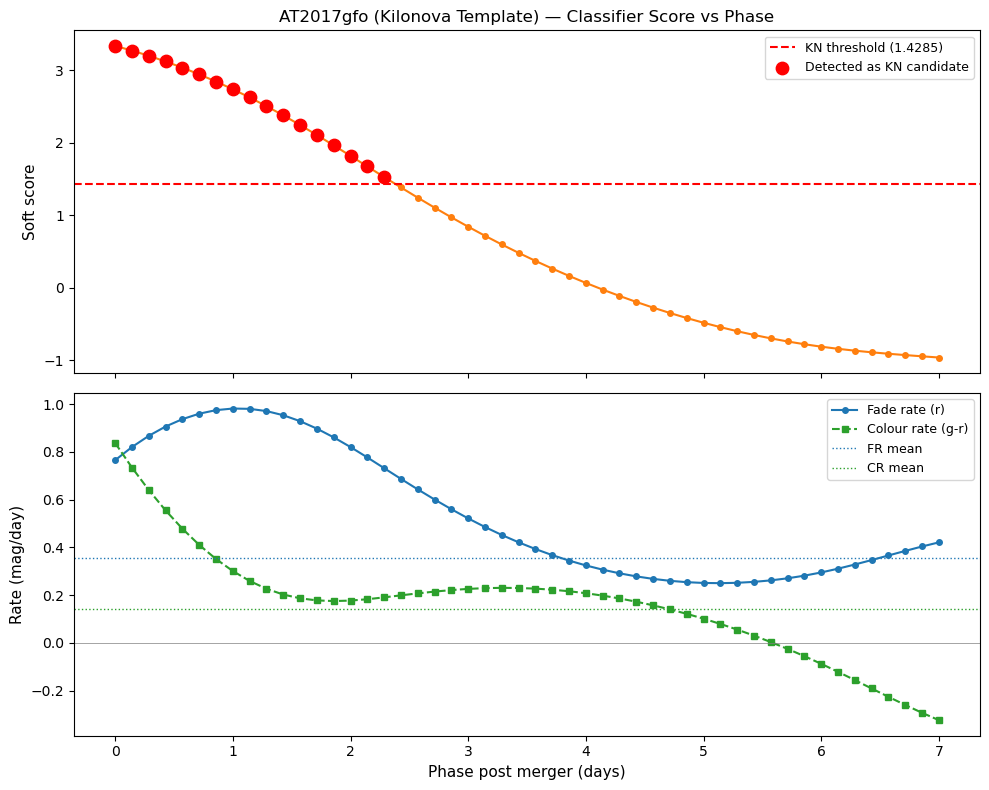

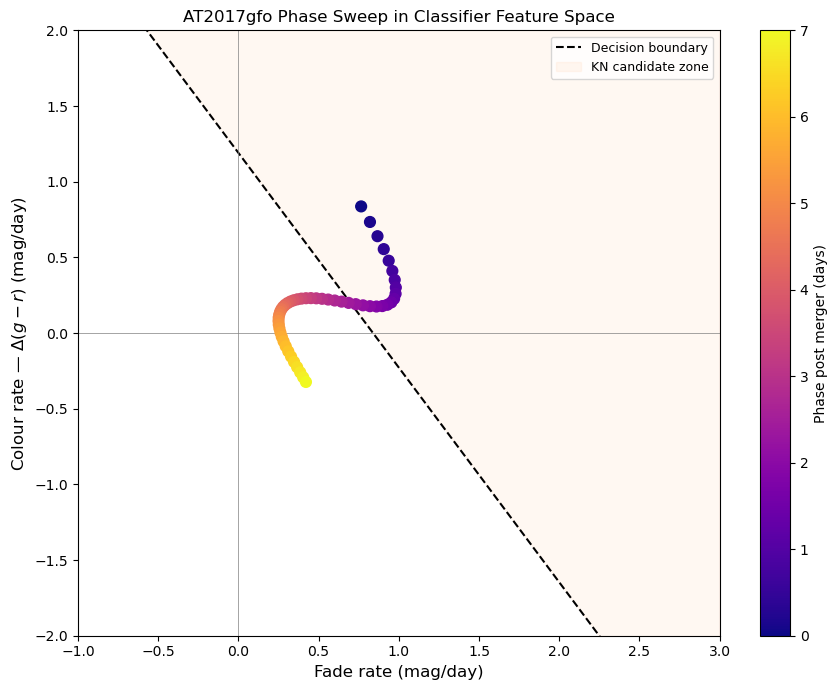

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(sweep_kn['phase'], sweep_kn['soft_score'], 'o-', markersize=4, color='C1')
ax.axhline(DEPLOY_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'KN threshold ({DEPLOY_THRESHOLD})')
ax.scatter(detected['phase'], detected['soft_score'],
           color='red', s=80, zorder=5, label='Detected as KN candidate')
ax.set_ylabel('Soft score', fontsize=11)
ax.set_title('AT2017gfo (Kilonova Template) — Classifier Score vs Phase', fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(sweep_kn['phase'], sweep_kn['fade_rate'], 'o-', markersize=4,
        color='C0', label='Fade rate (r)')
ax.plot(sweep_kn['phase'], sweep_kn['colour_rate'], 's--', markersize=4,
        color='C2', label='Colour rate (g-r)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axhline(DEPLOY_FR_MEAN, color='C0', linestyle=':', linewidth=1, label='FR mean')
ax.axhline(DEPLOY_CS_MEAN, color='C2', linestyle=':', linewidth=1, label='CR mean')
ax.set_xlabel('Phase post merger (days)', fontsize=11)
ax.set_ylabel('Rate (mag/day)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))

fr_grid = np.linspace(-1, 3, 300)
cr_boundary = DEPLOY_CS_MEAN + DEPLOY_CS_STD * (
    DEPLOY_THRESHOLD - (fr_grid - DEPLOY_FR_MEAN) / DEPLOY_FR_STD
)
ax.plot(fr_grid, cr_boundary, 'k--', linewidth=1.5, label='Decision boundary')
ax.fill_between(fr_grid, cr_boundary, 3, alpha=0.05, color='C1', label='KN candidate zone')

sc = ax.scatter(sweep_kn['fade_rate'], sweep_kn['colour_rate'],
                c=sweep_kn['phase'], cmap='plasma', s=60, zorder=4,
                vmin=0, vmax=7)
plt.colorbar(sc, ax=ax, label='Phase post merger (days)')



ax.set_xlabel('Fade rate (mag/day)', fontsize=12)
ax.set_ylabel('Colour rate — $\\Delta(g-r)$ (mag/day)', fontsize=12)
ax.set_title('AT2017gfo Phase Sweep in Classifier Feature Space', fontsize=12)
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 2)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [60]:
colour_rates_actual = []
first_epochs = []

for seed in range(1, 101):
    np.random.seed(seed)
    kn_d  = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)

    kn_r, _ = generate_observed_lightcurve('KN', kn_t0, kn_d)
    kn_g, _ = generate_observed_lightcurve_g('KN', kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan

    valid = (~np.isnan(kn_r)) & (~np.isnan(kn_g))
    if valid.sum() < 2:
        colour_rates_actual.append(np.nan)
        first_epochs.append(np.nan)
        continue

    idx = np.where(valid)[0]
    t0_obs, t1_obs = t_obs[idx[0]], t_obs[idx[1]]
    gr0 = kn_g[idx[0]] - kn_r[idx[0]]
    gr1 = kn_g[idx[1]] - kn_r[idx[1]]
    cr  = (gr1 - gr0) / (t1_obs - t0_obs)

    colour_rates_actual.append(cr)
    first_epochs.append(t0_obs)

colour_rates_actual = np.array(colour_rates_actual)
first_epochs        = np.array(first_epochs)

valid_mask = np.isfinite(colour_rates_actual)
print(f"KN events with >=2 detections: {valid_mask.sum()} / 100")
print(f"Mean first detection epoch:     {first_epochs[valid_mask].mean():.2f} days post merger")
print(f"Median first detection epoch:   {np.median(first_epochs[valid_mask]):.2f} days")
print()
print(f"Actual g-r colour rate seen by classifier:")
print(f"  Mean:   {colour_rates_actual[valid_mask].mean():.3f} mag/day")
print(f"  Median: {np.median(colour_rates_actual[valid_mask]):.3f} mag/day")
print(f"  Min:    {colour_rates_actual[valid_mask].min():.3f} mag/day")
print(f"  Max:    {colour_rates_actual[valid_mask].max():.3f} mag/day")
print()
print("Template reference values:")
print(f"  t=0 to t=1: 0.837 mag/day")
print(f"  t=1 to t=2: 0.301 mag/day")
print(f"  t=2 to t=3: 0.177 mag/day")

KN events with >=2 detections: 100 / 100
Mean first detection epoch:     0.00 days post merger
Median first detection epoch:   0.00 days

Actual g-r colour rate seen by classifier:
  Mean:   0.549 mag/day
  Median: 0.589 mag/day
  Min:    -0.647 mag/day
  Max:    1.631 mag/day

Template reference values:
  t=0 to t=1: 0.837 mag/day
  t=1 to t=2: 0.301 mag/day
  t=2 to t=3: 0.177 mag/day


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AT2017gfo angle closest to GW170817 inclination
bulla_angle = 1  # cos θ = 0.9, ~26° from pole
times, g_bulla, r_bulla = parse_possis('possis_sample.txt', viewing_angle=bulla_angle)

# Only plot first 10 days where flux is valid
mask = (times > 0.05) & (times < 10)
t = times[mask]

# Shift Bulla model to match AT2017gfo peak magnitude
# r-band
r_b = r_bulla[mask]
valid_r = np.isfinite(r_b)
r_peak_bulla = np.nanmin(r_b)
r_peak_kn    = spline_kn(np.array([phase_kn_sorted.min()]))[0]
r_shift = r_peak_kn - r_peak_bulla

# g-band
g_b = g_bulla[mask]
valid_g = np.isfinite(g_b)
g_peak_bulla = np.nanmin(g_b)
g_peak_kn    = spline_kn_g(np.array([phase_kn_g_sorted.min()]))[0]
g_shift = g_peak_kn - g_peak_bulla

# --- r-band panel ---
ax = axes[0]
# AT2017gfo data points
ax.scatter(phase_kn_sorted, M_kn_sorted + kn_offset,
           s=30, color='C1', label='AT2017gfo detections', zorder=5)
ax.scatter(phase_kn_lim, M_kn_lim + kn_offset,
           marker='v', s=50, color='C1', edgecolor='black',
           linewidth=0.5, label='AT2017gfo upper limits', zorder=5)
# AT2017gfo spline
t_spl = np.linspace(0.1, 9, 200)
ax.plot(t_spl, spline_kn(t_spl), color='C1', linewidth=2,
        linestyle='--', label='AT2017gfo spline')
# Bulla model
ax.plot(t[valid_r], r_b[valid_r] + r_shift, color='steelblue',
        linewidth=2, label=f'Bulla model (angle={bulla_angle}, ~26°)')

ax.invert_yaxis()
ax.set_xlabel('Days since merger')
ax.set_ylabel('Absolute r-band magnitude')
ax.set_title('r-band: AT2017gfo vs Bulla model\n(mejdyn=0.01, mejwind=0.09, phi=30°)')
ax.set_xlim(0, 9)
ax.legend(fontsize=8, frameon=False)

# --- g-band panel ---
ax = axes[1]
ax.scatter(phase_kn_g_sorted, M_kn_g_sorted + kn_offset,
           s=30, color='C1', label='AT2017gfo detections', zorder=5)
ax.scatter(phase_kn_g_lim, M_kn_g_lim + kn_offset,
           marker='v', s=50, color='C1', edgecolor='black',
           linewidth=0.5, label='AT2017gfo upper limits', zorder=5)
ax.plot(t_spl, spline_kn_g(t_spl), color='C1', linewidth=2,
        linestyle='--', label='AT2017gfo spline')
ax.plot(t[valid_g], g_b[valid_g] + g_shift, color='steelblue',
        linewidth=2, label=f'Bulla model (angle={bulla_angle}, ~26°)')

ax.invert_yaxis()
ax.set_xlabel('Days since merger')
ax.set_ylabel('Absolute g-band magnitude')
ax.set_title('g-band: AT2017gfo vs Bulla model\n(mejdyn=0.01, mejwind=0.09, phi=30°)')
ax.set_xlim(0, 9)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('bulla_vs_at2017gfo.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\edcon\Downloads\kn_data\decam_photometry.csv')

# Get g and r, bin by night
gr = df[df['band'].isin(['g','r'])].copy()
gr['night'] = gr['mjd'].apply(np.floor)

g_nightly = gr[gr['band']=='g'].groupby('night')['mag'].mean().reset_index()
r_nightly = gr[gr['band']=='r'].groupby('night')['mag'].mean().reset_index()

print("r-band nightly:")
print(r_nightly.to_string())
print("\ng-band nightly:")
print(g_nightly.to_string())

# Fade rate: first two r nights
dt_r = r_nightly['night'].iloc[1] - r_nightly['night'].iloc[0]
dm_r = r_nightly['mag'].iloc[1] - r_nightly['mag'].iloc[0]
fade_rate = dm_r / dt_r

# g-r colour rate: first two paired nights
pairs = []
for _, rrow in r_nightly.iterrows():
    diff = (g_nightly['night'] - rrow['night']).abs()
    if diff.min() <= 1.0:
        g_mag = g_nightly.iloc[diff.argsort().iloc[0]]['mag']
        pairs.append({'night': rrow['night'], 'gr': g_mag - rrow['mag']})

dt_c = pairs[1]['night'] - pairs[0]['night']
colour_rate = (pairs[1]['gr'] - pairs[0]['gr']) / dt_c

print(f"\nFade rate: {fade_rate:.4f} mag/day")
print(f"Colour rate: {colour_rate:.4f} mag/day")

# Soft score
DEPLOY_FR_MEAN   = 0.3535
DEPLOY_FR_STD    = 0.2701
DEPLOY_CS_MEAN   = 0.1416
DEPLOY_CS_STD    = 0.3831
DEPLOY_THRESHOLD = 1.4285

z_fr = (fade_rate - DEPLOY_FR_MEAN) / DEPLOY_FR_STD
z_cs = (colour_rate - DEPLOY_CS_MEAN) / DEPLOY_CS_STD
score = z_fr + z_cs

print(f"\nSoft score: {score:.4f}")
print(f"Threshold: {DEPLOY_THRESHOLD}")
print(f"Classified as: {'KN' if score >= DEPLOY_THRESHOLD else 'non-KN'}")

r-band nightly:
     night     mag
0  57983.0  18.041
1  57984.0  19.035
2  57985.0  19.290
3  57986.0  20.252
4  57987.0  20.794
5  57988.0  20.948
6  57989.0  21.226
7  57990.0  21.952

g-band nightly:
     night     mag
0  57983.0  18.664
1  57984.0  20.209
2  57985.0  20.928
3  57986.0  21.731
4  57987.0  22.034
5  57988.0  22.082
6  57989.0  23.276

Fade rate: 0.9940 mag/day
Colour rate: 0.5510 mag/day

Soft score: 3.4400
Threshold: 1.4285
Classified as: KN


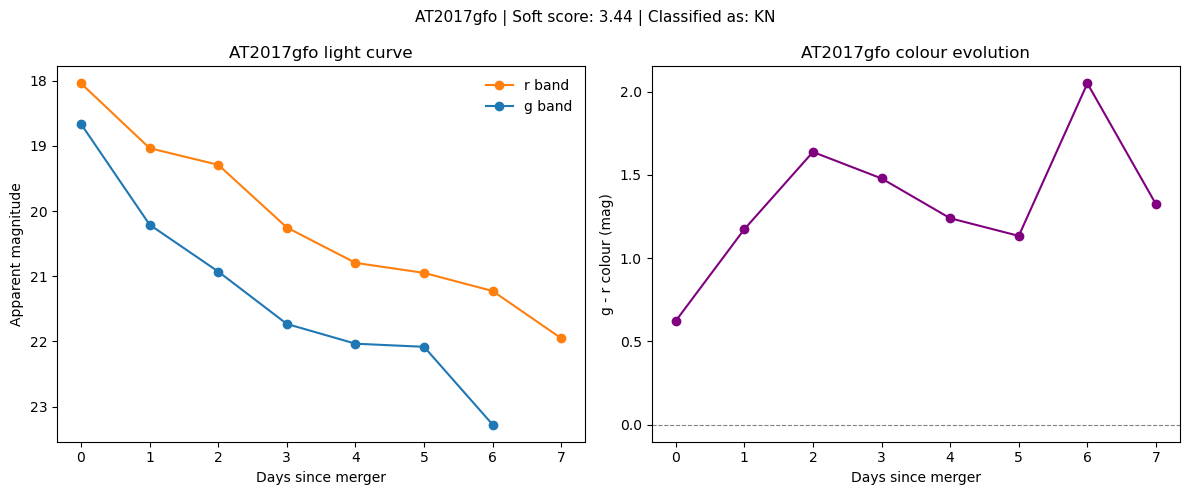

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Nightly data
r_mags = r_nightly['mag'].values
g_mags = g_nightly['mag'].values
r_nights = r_nightly['night'].values - r_nightly['night'].values[0]
g_nights = g_nightly['night'].values - g_nightly['night'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: light curves
axes[0].plot(r_nights, r_mags, 'o-', color='C1', label='r band')
axes[0].plot(g_nights, g_mags, 'o-', color='C0', label='g band')
axes[0].invert_yaxis()
axes[0].set_xlabel('Days since merger')
axes[0].set_ylabel('Apparent magnitude')
axes[0].set_title('AT2017gfo light curve')
axes[0].legend(frameon=False)

# Right panel: g-r colour evolution
common_nights = []
gr_colours = []
for i, rrow in r_nightly.iterrows():
    diff = (g_nightly['night'] - rrow['night']).abs()
    if diff.min() <= 1.0:
        g_mag = g_nightly.iloc[diff.argsort().iloc[0]]['mag']
        common_nights.append(rrow['night'] - r_nightly['night'].iloc[0])
        gr_colours.append(g_mag - rrow['mag'])

axes[1].plot(common_nights, gr_colours, 'o-', color='purple')
axes[1].set_xlabel('Days since merger')
axes[1].set_ylabel('g - r colour (mag)')
axes[1].set_title('AT2017gfo colour evolution')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle(f'AT2017gfo | Soft score: 3.44 | Classified as: KN', fontsize=11)
plt.tight_layout()
plt.show()